# Data preparation

In [1]:
!pip install pydicom
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from google.colab import auth
from google.cloud import bigquery, storage

# Authenticate and set up aenvironment
auth.authenticate_user()
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
!gcloud config set project {project_id}

# Initialize BigQuery client
client = bigquery.Client(project=project_id)

# Initialize GCP Storage client with user_project parameter
storage_client = storage.Client(project=project_id)
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name, user_project=project_id)

# Path to the filtered combined data CSV in your GCP bucket
filtered_data_path = 'final_combined_data.csv'
filtered_blob = bucket.blob(filtered_data_path)

# Download the filtered combined data CSV to a local temporary file
local_filtered_data_path = '/tmp/filtered_combined_data.csv'
filtered_blob.download_to_filename(local_filtered_data_path)

# Load the filtered combined data CSV into a DataFrame
df = pd.read_csv(local_filtered_data_path)


# Extract embedding vectors
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
print (embeddings)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.8 MB/s eta 0:00:00
Updated property [core/project].
      embedding_0  embedding_1  embedding_2  embedding_3  embedding_4  \
0       -1.740258    -0.782546     0.805217    -1.685203    -0.150928   
1       -0.911495    -0.515437     0.619245    -2.373145    -0.171805   
2       -1.034045    -0.783105     0.583782    -1.079196     0.196727   
3       -1.498975    -0.566318     0.506368    -1.586067     0.069659   
4       -0.716697    -0.587135     1.320426    -2.036464    -0.071745   
...           ...          ...          ...          ...          ...   
1112    -1.295518    -0.371794     0.170809    -2.018295     0.624668   
1113    -0.767546    -0.130139     0.142088    -2.607982    -0.953248   
1114    -0.091549    -1.316677     0.362403    -2.207046     0.192631   
1115     0.394565    -0.205986     1.213435    -1.648330     0.394253   
1116    -0.996493    -1.363348     0.844462    -1.462523     0.076252   

      embeddi

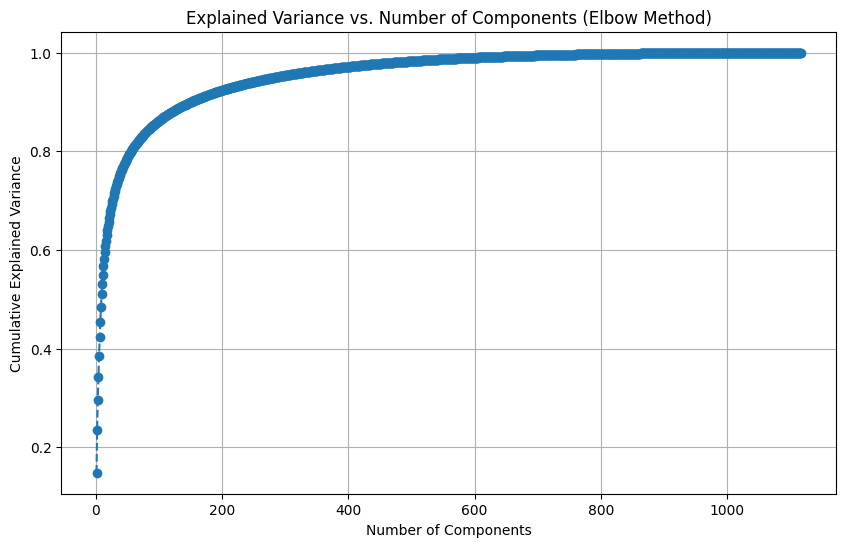

The optimal number of components based on silhouette score is: 62
[[-4.62993837  2.18177171 -3.13937452 ... -0.22300251 -0.29225417
   0.79714773]
 [-3.84081017  1.38279085  1.29619876 ... -1.62216964  1.23492815
   0.49527604]
 [-5.97690624 -0.35364261 -0.22087192 ... -0.79576784 -0.72903351
  -0.53131924]
 ...
 [-3.41695376  3.7709602  -6.04413886 ...  1.60461765  0.44749785
  -1.168415  ]
 [14.07613177 -6.67155879  3.9994167  ...  0.22412485  0.4846685
   0.98134147]
 [-9.28944469  2.48160608 -3.18441926 ...  0.68979843 -0.13547684
   0.04768824]]
62
1117


In [2]:
# Determine the optimal number of PCA components using the elbow method
pca = PCA()
embeddings_pca = pca.fit_transform(embeddings)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance to use the elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components (Elbow Method)')
plt.grid()
plt.show()

# Using the Silhouette method to determine the optimal number of components
def optimal_number_of_components(data, max_components=10):
    silhouette_scores = []
    for n_components in range(2, max_components + 1):
        pca = PCA(n_components=n_components)
        transformed_data = pca.fit_transform(data)
        kmeans = KMeans(n_clusters=n_components, n_init=10)  # Explicitly set n_init
        kmeans.fit(transformed_data)
        score = silhouette_score(transformed_data, kmeans.labels_)
        silhouette_scores.append(score)

    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_components + 1), silhouette_scores, marker='o', linestyle='--')
    plt.xlabel('Number of Components')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs. Number of Components')
    plt.grid()
    plt.show()

    optimal_components = np.argmax(silhouette_scores) + 2  # +2 because range starts at 2
    return optimal_components

# Display optimal number of features using silhouette score
optimal_components = 62
print(f'The optimal number of components based on silhouette score is: {optimal_components}')

# Apply PCA with optimal number of components
pca = PCA(n_components=optimal_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

print (embeddings_pca)
print (len(embeddings_pca[0]))
print (len(embeddings_pca))

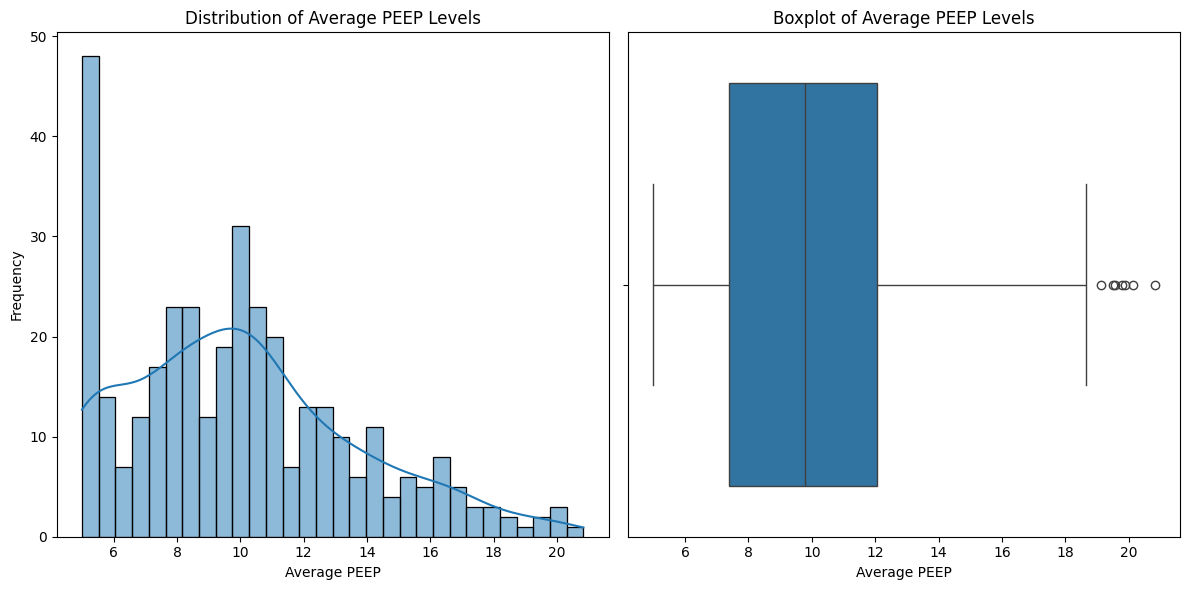

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming embeddings and avg_peep are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract the avg_peep column
avg_peep = df['avg_peep']

# Plot the distribution of avg_peep levels
plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(avg_peep, bins=30, kde=True)
plt.xlabel('Average PEEP')
plt.ylabel('Frequency')
plt.title('Distribution of Average PEEP Levels')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=avg_peep)
plt.xlabel('Average PEEP')
plt.title('Boxplot of Average PEEP Levels')

plt.tight_layout()
plt.show()


In [5]:
import numpy as np
import pandas as pd

# Assuming df is your DataFrame and avg_peep is the column of interest
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract the avg_peep column
avg_peep = df['avg_peep']

# Count the number of data points in each range
less_than_10 = (avg_peep < 10).sum()
#between_8_and_11 = ((avg_peep >= 8) & (avg_peep <= 11)).sum()
#greater_than_11 = (avg_peep > 11).sum()

# Print the counts
print(f'Number of avg_peep data points less than 8: {less_than_10}')
#print(f'Number of avg_peep data points between 8 and 12: {between_8_and_11}')
#print(f'Number of avg_peep data points greater than or equal to 10: {greater_than_11}')


Number of avg_peep data points less than 8: 182


# PCA

In [13]:
# Choose the number of components based on the elbow method graph
chosen_components = 62

# Apply PCA with chosen number of components
pca = PCA(n_components=chosen_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]
    print(df[f'pca_{i+1}'])

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(chosen_components)]]
y = df['avg_peep']

# Univariate PCA logistic regression (changing from multivariate to univariate)
# Here we use each PCA component individually to fit the regression model
significant_components = []
for i in range(chosen_components):
    Xi = sm.add_constant(X[[f'pca_{i+1}']])
    model = sm.OLS(y, Xi)
    result = model.fit()
    p_value = result.pvalues[f'pca_{i+1}']
    if p_value < 0.1:
        significant_components.append(i+1)
        print(f'Regression summary for PCA component {i+1}')
        print(result.summary())
        print (significant_components)

0       -4.629938
1       -3.840810
2       -5.976906
3       -6.907544
4       -7.304151
          ...    
1112    -2.777568
1113   -14.373339
1114    -3.416954
1115    14.076132
1116    -9.289445
Name: pca_1, Length: 1117, dtype: float64
0       2.181772
1       1.382791
2      -0.353643
3      -1.356149
4       4.586390
          ...   
1112   -2.756661
1113    3.938681
1114    3.770960
1115   -6.671559
1116    2.481606
Name: pca_2, Length: 1117, dtype: float64
0      -3.139375
1       1.296199
2      -0.220872
3      -4.196812
4      -0.529736
          ...   
1112    4.556182
1113   -3.699443
1114   -6.044139
1115    3.999417
1116   -3.184419
Name: pca_3, Length: 1117, dtype: float64
0        2.223444
1       -0.428715
2       -2.678657
3       -3.025902
4        7.642475
          ...    
1112     6.232000
1113    -3.331032
1114    -1.043428
1115    18.302171
1116    -1.276551
Name: pca_4, Length: 1117, dtype: float64
0        1.078878
1        0.886510
2        2.192489
3       

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


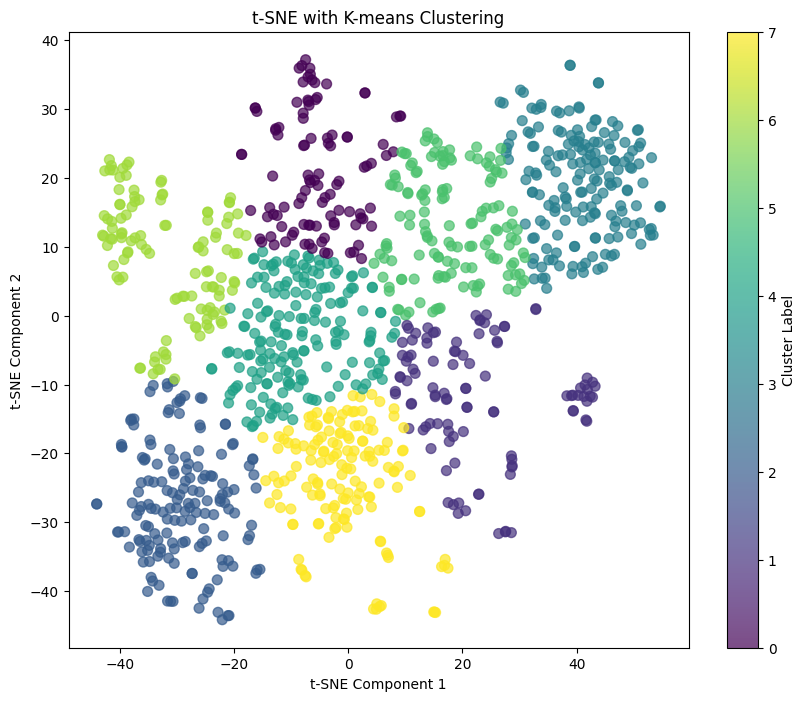

In [19]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Step 1: Apply PCA to reduce the embedding dimensions to 62 components
chosen_components = 62
pca = PCA(n_components=chosen_components)
embeddings_pca = pca.fit_transform(embeddings)

# Step 2: Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for t-SNE
X_pca = df[[f'pca_{i+1}' for i in range(chosen_components)]]

# Step 3: Apply t-SNE to reduce dimensions from 62 to 2 components
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# Add t-SNE components to the dataframe for visualization and clustering
df['tsne_1'] = X_tsne[:, 0]
df['tsne_2'] = X_tsne[:, 1]

# Step 4: Perform K-means clustering with 6 clusters on the t-SNE components
kmeans = KMeans(n_clusters=8, random_state=42)
df['cluster'] = kmeans.fit_predict(X_tsne)

# Step 5: Visualize the t-SNE results with K-means clusters
plt.figure(figsize=(10, 8))
plt.scatter(df['tsne_1'], df['tsne_2'], c=df['cluster'], cmap='viridis', marker='o', s=50, alpha=0.7)
plt.title('t-SNE with K-means Clustering')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='Cluster Label')
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

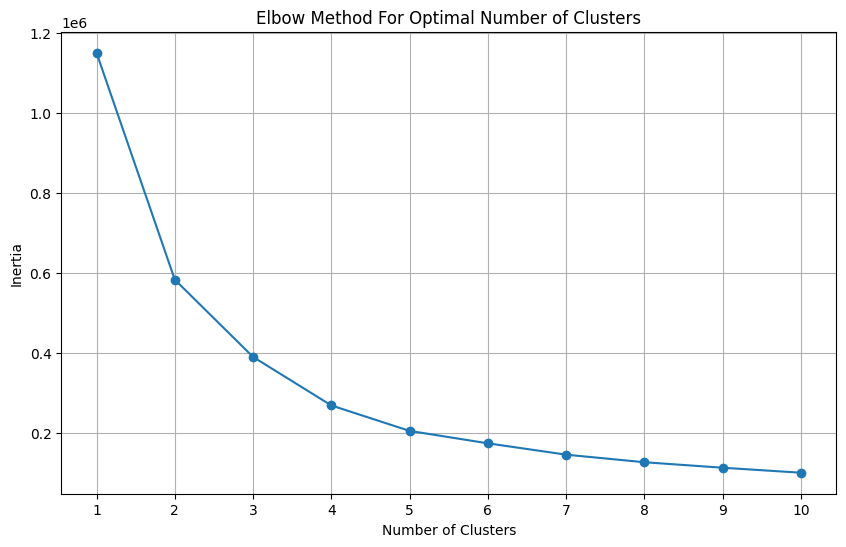

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Define a range of possible cluster numbers
cluster_range = range(1, 11)
inertia = []

# Perform K-means clustering for each number of clusters and compute inertia
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_tsne)  # X_tsne is the t-SNE reduced data
    inertia.append(kmeans.inertia_)

# Plot the inertia for each number of clusters
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertia, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()


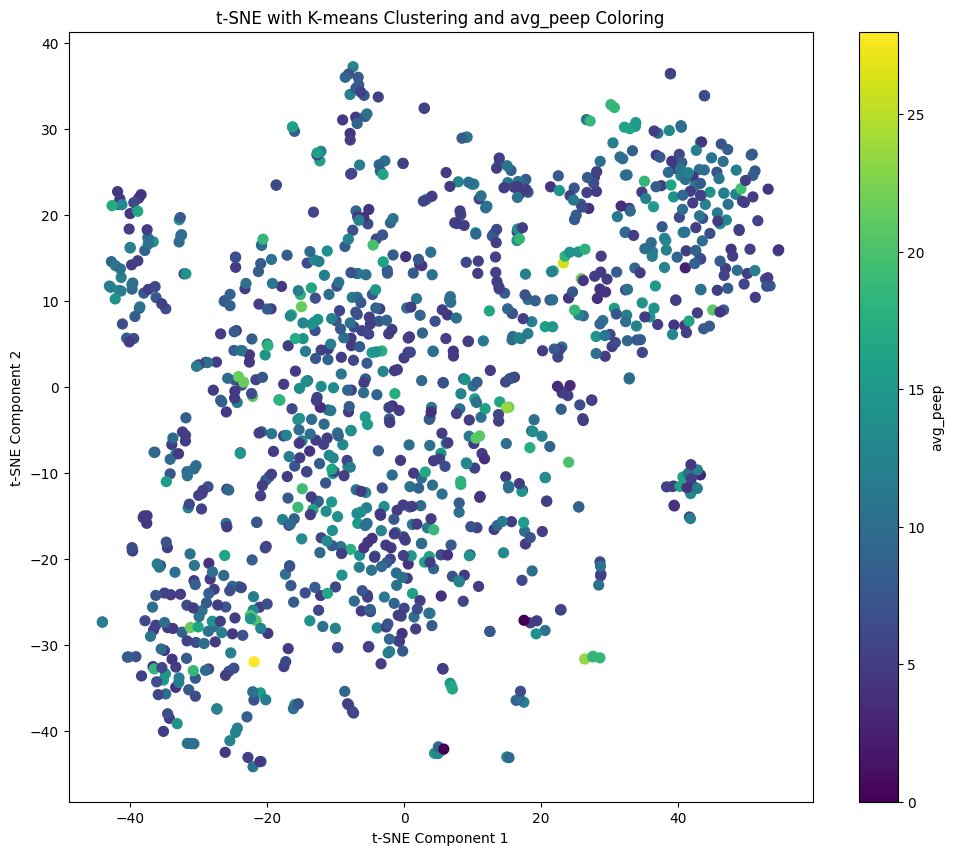

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 5: Visualize the t-SNE results with K-means clusters and avg_peep coloring
plt.figure(figsize=(12, 10))

# Plot the scatter plot with larger dots and using the actual avg_peep values without normalization
scatter = plt.scatter(x=df['tsne_1'], y=df['tsne_2'], c=df['avg_peep'], cmap='viridis', s=50)  # Increased 's' to 50 for larger dots

plt.title('t-SNE with K-means Clustering and avg_peep Coloring')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# Add a colorbar using the scatterplot object
plt.colorbar(scatter, label='avg_peep')
plt.show()


In [58]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Assuming you have already loaded and processed the data as in your provided code
# Step 1: Apply PCA to reduce the embedding dimensions to 62 components
chosen_components = 62
pca = PCA(n_components=chosen_components)
embeddings_pca = pca.fit_transform(embeddings)

# Step 2: Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Step 3: Apply t-SNE to reduce dimensions from 62 to 2 components
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(embeddings_pca)

# Add t-SNE components to the dataframe for visualization and clustering
df['tsne_1'] = X_tsne[:, 0]
df['tsne_2'] = X_tsne[:, 1]

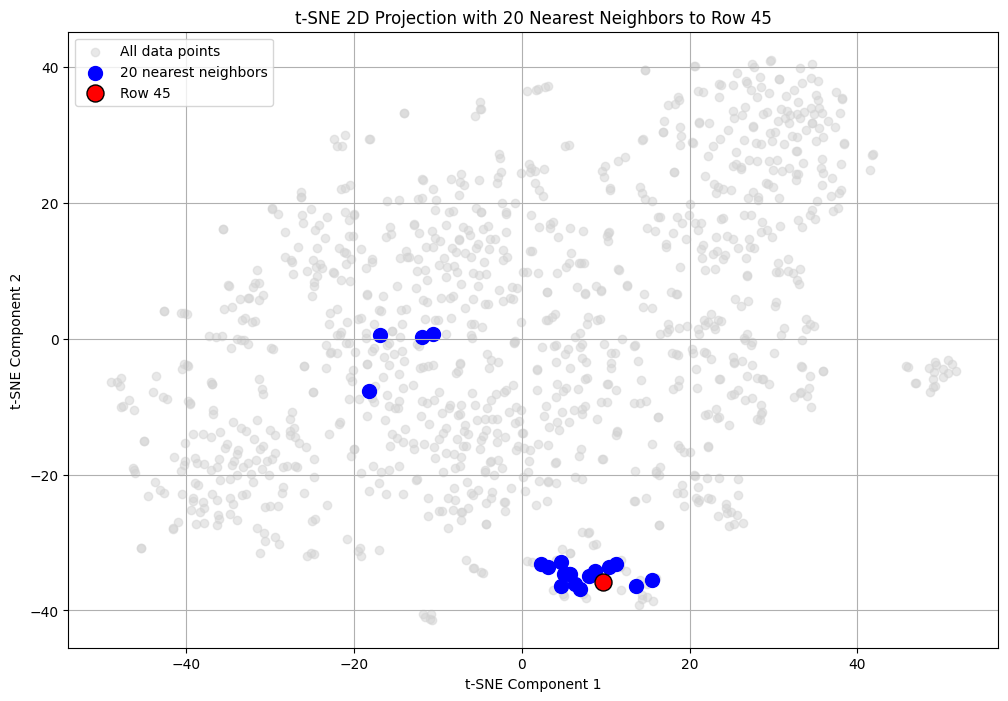

In [56]:
# Step 4: Choose a specific row and find its 50 nearest neighbors
row_index = 45  # Example row index; change as needed
n_neighbors = 20

# Extract the data from the chosen row
query_row = embeddings_pca[row_index].reshape(1, -1)

# Initialize the NearestNeighbors model
nn_model = NearestNeighbors(n_neighbors=n_neighbors+1, algorithm='auto', metric='euclidean')
nn_model.fit(embeddings_pca)

# Find the nearest neighbors
distances, indices = nn_model.kneighbors(query_row)

# Exclude the first neighbor (the row itself)
nearest_neighbors_indices = indices.flatten()[1:]

# Step 5: Visualize the t-SNE results highlighting the chosen row and its neighbors
plt.figure(figsize=(12, 8))

# Plot all points
plt.scatter(df['tsne_1'], df['tsne_2'], c='lightgray', alpha=0.5, label='All data points')

# Highlight the 50 nearest neighbors
plt.scatter(df.iloc[nearest_neighbors_indices]['tsne_1'], df.iloc[nearest_neighbors_indices]['tsne_2'], c='blue', label=f'{n_neighbors} nearest neighbors', s=100)

# Highlight the chosen row
plt.scatter(df.iloc[row_index]['tsne_1'], df.iloc[row_index]['tsne_2'], c='red', label=f'Row {row_index}', edgecolors='black', s=150)

# Add labels and legend
plt.title(f't-SNE 2D Projection with {n_neighbors} Nearest Neighbors to Row {row_index}')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.grid(True)
plt.show()


<ipython-input-57-3419e8395c24>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nearest_neighbors_df['rounded_peep'] = nearest_neighbors_df['avg_peep'].round()


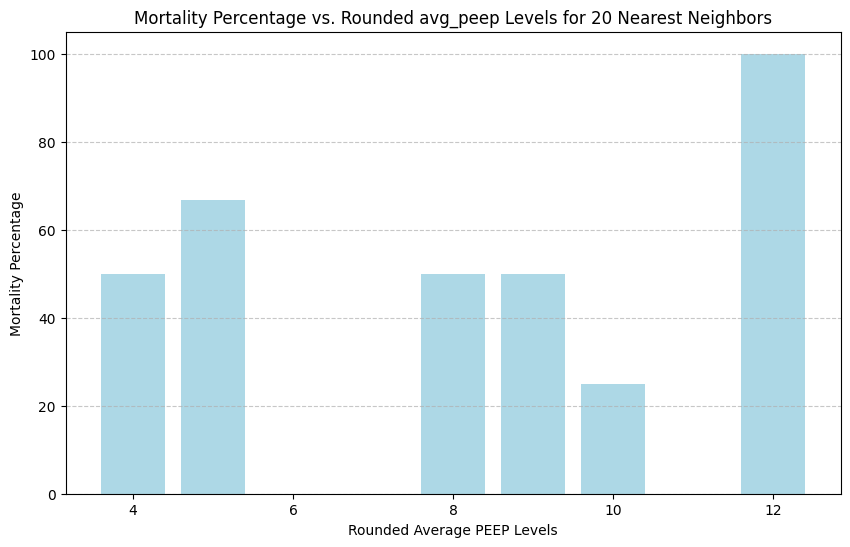

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df contains the columns 'avg_peep' and 'icu_mort'
# Filter the nearest neighbors' data
nearest_neighbors_df = df.iloc[nearest_neighbors_indices]

# Step 1: Round the avg_peep values to the nearest integer
nearest_neighbors_df['rounded_peep'] = nearest_neighbors_df['avg_peep'].round()

# Step 2: Group by rounded avg_peep and calculate the mortality rate
# Mortality rate is calculated as the mean of icu_mort
grouped_data = nearest_neighbors_df.groupby('rounded_peep')['icu_mort'].mean().reset_index()

# Step 3: Multiply the mortality rate by 100 to convert it to percentage
grouped_data['mortality_percentage'] = grouped_data['icu_mort'] * 100

# Step 4: Plotting the 2D bar chart with mortality percentage
plt.figure(figsize=(10, 6))
plt.bar(grouped_data['rounded_peep'], grouped_data['mortality_percentage'], color='lightblue')

plt.xlabel('Rounded Average PEEP Levels')
plt.ylabel('Mortality Percentage')
plt.title(f'Mortality Percentage vs. Rounded avg_peep Levels for {n_neighbors} Nearest Neighbors')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [8]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Assuming embeddings and avg_peep are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and avg_peep
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]

# Choose the number of components based on the elbow method graph
chosen_components = 50

# Apply PCA with chosen number of components
pca = PCA(n_components=chosen_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(chosen_components)]]
y = df['avg_peep']

# Univariate PCA regression analysis
results_list = []

for i in range(chosen_components):
    Xi = sm.add_constant(X[[f'pca_{i+1}']])
    model = sm.OLS(y, Xi)
    result = model.fit()
    p_value = result.pvalues[f'pca_{i+1}']
    confidence_interval = result.conf_int().loc[f'pca_{i+1}'].values
    r_squared = r2_score(y, result.predict(Xi))
    coefficient = result.params[f'pca_{i+1}']

    results_list.append({
        'PCA Component': f'pca_{i+1}',
        'Coefficient': coefficient,
        'P-Value': p_value,
        'R-Squared': r_squared,
        'Confidence Interval': confidence_interval
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results_list)

# Display the table
print(results_df)

# Filter significant components based on p-value < 0.1
significant_components_df = results_df[results_df['P-Value'] < 0.1]

# Display the significant components
print("\nSignificant Components (P-Value < 0.1):")
print(significant_components_df)


   PCA Component  Coefficient       P-Value     R-Squared  \
0          pca_1    -0.028774  2.820655e-01  3.305282e-03   
1          pca_2     0.024965  4.543253e-01  1.600543e-03   
2          pca_3    -0.067142  1.038108e-01  7.542215e-03   
3          pca_4    -0.008357  8.617262e-01  8.679928e-05   
4          pca_5    -0.047148  3.689780e-01  2.306642e-03   
5          pca_6     0.378089  8.511777e-13  1.361698e-01   
6          pca_7    -0.083091  1.449870e-01  6.059427e-03   
7          pca_8     0.022021  7.180992e-01  3.728092e-04   
8          pca_9     0.085333  1.786487e-01  5.162100e-03   
9         pca_10     0.061366  3.855835e-01  2.151683e-03   
10        pca_11     0.065213  3.609512e-01  2.385076e-03   
11        pca_12     0.043163  5.927134e-01  8.183383e-04   
12        pca_13    -0.082498  3.433056e-01  2.566221e-03   
13        pca_14     0.074852  4.062134e-01  1.971887e-03   
14        pca_15     0.052280  5.739666e-01  9.039979e-04   
15        pca_16    -0.0

# PCA intensity-initiation


In [3]:
import tensorflow as tf

def parse_tfrecord_fn(example):
    feature_description = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }
    example = tf.io.parse_single_example(example, feature_description)
    embedding = example['embedding']
    image_format = example['image/format']
    image_id = example['image/id']
    return embedding, image_format, image_id

def load_embeddings_and_image_ids(tfrecord_path):
    raw_dataset = tf.data.TFRecordDataset(tfrecord_path)
    parsed_dataset = raw_dataset.map(parse_tfrecord_fn)
    embeddings = []
    image_ids = []
    for embedding, image_format, image_id in parsed_dataset:
        embeddings.append(embedding.numpy())
        image_ids.append(image_id.numpy().decode('utf-8'))
    return embeddings, image_ids

tfrecord_path = '/tmp/example1.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.tfrecord')
blob.download_to_filename(tfrecord_path)

# Load embeddings and image IDs from the TFRecord
embeddings, image_ids = load_embeddings_and_image_ids(tfrecord_path)


NameError: name 'bucket' is not defined

In [ ]:
!pip install pydicom
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example1.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example1.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

# Function to parse TFRecord file
def _parse_function(proto):
    # Define your features
    keys_to_features = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }

    # Load one example
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    return parsed_features['embedding']

# Path to the TFRecord file
tfrecord_path = '/tmp/example1.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.tfrecord')
blob.download_to_filename(tfrecord_path)

# Create a dataset from the TFRecord file
dataset = tf.data.TFRecordDataset([tfrecord_path])
dataset = dataset.map(_parse_function)

# Extract embeddings (assuming there's only one record in the file for simplicity)
for record in dataset.take(1):
    pca_features = record.numpy()

# Directly use significant components from regression analysis
significant_components = [5, 6, 17, 24, 26]  # Ensure these are within the range of pca_features

# Define ROIs (divide the image into an 8x8 grid)
height, width = image_array.shape
num_rois = 8
roi_height, roi_width = height // num_rois, width // num_rois

rois = [
    (slice(i * roi_height, (i + 1) * roi_height), slice(j * roi_width, (j + 1) * roi_width))
    for i in range(num_rois) for j in range(num_rois)
]

# Create an empty mask for the full image
red_mask_full = np.zeros_like(image_array, dtype=np.float32)

# Threshold for visualization
threshold = 1e4  # Example threshold value, adjust based on your data

# Calculate and visualize PCA intensities for each ROI
for component in significant_components:
    if component - 1 >= len(pca_features):
        print(f"Component {component} is out of bounds for PCA features with length {len(pca_features)}")
        continue

    pca_feature = pca_features[component - 1]

    for roi in rois:
        # Extract the region from the DICOM image
        roi_image = image_array[roi]

        # Calculate the mean intensity of the PCA feature within this ROI
        pca_intensity = np.mean(roi_image) * pca_feature
        print(f"ROI {roi}: PCA Component {component}, Intensity: {pca_intensity}")

        # Apply the intensity to the full image mask if it exceeds the threshold
        if abs(pca_intensity) > threshold:
            red_mask_full[roi] += pca_intensity

# Normalize the DICOM image to the range [0, 1]
image_normalized = image_array.astype(np.float32) / np.max(image_array)

# Create the overlay image with a semi-transparent red mask
alpha = 0.5
overlay_image = np.zeros((*image_array.shape, 3), dtype=np.float32)
overlay_image[..., 0] = np.clip(image_normalized + alpha * red_mask_full, 0, 1)  # Red channel
overlay_image[..., 1] = image_normalized  # Green channel
overlay_image[..., 2] = image_normalized  # Blue channel

# Display the overlay image
plt.figure(figsize=(10, 10))
plt.imshow(overlay_image)
plt.title('DICOM Image with PCA Features Highlighted in Red')
plt.axis('off')
plt.show()

# Visualize the ROIs on the original image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
for roi in rois:
    plt.gca().add_patch(plt.Rectangle((roi[1].start, roi[0].start), roi[1].stop - roi[1].start, roi[0].stop - roi[0].start, edgecolor='red', facecolor='none', linewidth=2))
plt.title('ROIs on DICOM Image')
plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example1.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

# Function to parse TFRecord file
def _parse_function(proto):
    # Define your features
    keys_to_features = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }

    # Load one example
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    return parsed_features['embedding']

# Path to the TFRecord file
tfrecord_path = '/tmp/example1.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.tfrecord')
blob.download_to_filename(tfrecord_path)

# Create a dataset from the TFRecord file
dataset = tf.data.TFRecordDataset([tfrecord_path])
dataset = dataset.map(_parse_function)

# Extract embeddings (assuming there's only one record in the file for simplicity)
for record in dataset.take(1):
    pca_features = record.numpy()

# Directly use significant components from regression analysis
significant_components = [5, 6, 17, 24, 26]  # Ensure these are within the range of pca_features

# Define ROIs (divide the image into a 40x40 grid)
height, width = image_array.shape
num_rois = 60
roi_height, roi_width = height // num_rois, width // num_rois

rois = [
    (slice(i * roi_height, (i + 1) * roi_height), slice(j * roi_width, (j + 1) * roi_width))
    for i in range(num_rois) for j in range(num_rois)
]

# Create an empty mask for the full image
intensity_map = np.zeros((num_rois, num_rois))

# Calculate PCA intensities for each ROI and store them in the intensity map
for i, roi in enumerate(rois):
    roi_intensity = 0
    for component in significant_components:
        if component - 1 >= len(pca_features):
            print(f"Component {component} is out of bounds for PCA features with length {len(pca_features)}")
            continue

        pca_feature = pca_features[component - 1]

        # Extract the region from the DICOM image
        roi_image = image_array[roi]

        # Calculate the mean intensity of the PCA feature within this ROI
        pca_intensity = np.mean(roi_image) * pca_feature
        roi_intensity += pca_intensity

    intensity_map[i // num_rois, i % num_rois] = roi_intensity

# Normalize the intensity map for color mapping
intensity_map_normalized = (intensity_map - np.min(intensity_map)) / (np.max(intensity_map) - np.min(intensity_map))

# Create the overlay image with a color map and transparency
overlay_image = np.zeros((*image_array.shape, 3), dtype=np.float32)
alpha = 0.98  # Transparency level

for i, roi in enumerate(rois):
    intensity = intensity_map_normalized[i // num_rois, i % num_rois]
    color = plt.cm.jet(intensity)[:3]  # Use a colormap (e.g., 'jet') to get the color
    for j in range(3):  # Apply color to the RGB channels
        overlay_image[roi[0], roi[1], j] = (1 - alpha) * (image_array[roi] / 255) + alpha * color[j]

# Display the overlay image
plt.figure(figsize=(10, 10))
plt.imshow(overlay_image)
plt.title('DICOM Image with PCA Intensities Highlighted')
plt.axis('off')
plt.show()

# Display the intensity map for reference
plt.figure(figsize=(10, 10))
plt.imshow(intensity_map, cmap='jet')
plt.colorbar(label='PCA Intensity')
plt.title('PCA Intensity Map')
plt.show()

# Print the intensity values for each ROI
for i, roi in enumerate(rois):
    print(f"ROI {roi}: Intensity: {intensity_map[i // num_rois, i % num_rois]}")


# PCA intensity colour mapping_final

In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example1.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Function to parse TFRecord file
def _parse_function(proto):
    # Define your features
    keys_to_features = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }

    # Load one example
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    return parsed_features['embedding']

# Path to the TFRecord file
tfrecord_path = '/tmp/example1.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.tfrecord')
blob.download_to_filename(tfrecord_path)

# Create a dataset from the TFRecord file
dataset = tf.data.TFRecordDataset([tfrecord_path])
dataset = dataset.map(_parse_function)

# Extract embeddings (assuming there's only one record in the file for simplicity)
for record in dataset.take(1):
    pca_features = record.numpy()

# Directly use significant components from regression analysis
significant_components = [5, 6, 17, 24, 26]  # Ensure these are within the range of pca_features

# Define ROIs (divide the image into a 40x40 grid)
height, width = image_array.shape
num_rois = 100
roi_height, roi_width = height // num_rois, width // num_rois

rois = [
    (slice(i * roi_height, (i + 1) * roi_height), slice(j * roi_width, (j + 1) * roi_width))
    for i in range(num_rois) for j in range(num_rois)
]

# Threshold for visualization
threshold = 1e4  # Example threshold value, adjust based on your data

for component in significant_components:
    if component - 1 >= len(pca_features):
        print(f"Component {component} is out of bounds for PCA features with length {len(pca_features)}")
        continue

    # Create an empty mask for the full image
    intensity_map = np.zeros((num_rois, num_rois))

    # Calculate PCA intensities for each ROI and store them in the intensity map
    for i, roi in enumerate(rois):
        pca_feature = pca_features[component - 1]

        # Extract the region from the DICOM image
        roi_image = image_array[roi]

        # Calculate the mean intensity of the PCA feature within this ROI
        pca_intensity = np.mean(roi_image) * pca_feature

        intensity_map[i // num_rois, i % num_rois] = pca_intensity

    # Normalize the intensity map for color mapping
    intensity_map_normalized = (intensity_map - np.min(intensity_map)) / (np.max(intensity_map) - np.min(intensity_map))

    # Create the overlay image with a color map and transparency
    overlay_image = np.zeros((*image_array.shape, 3), dtype=np.float32)
    alpha = 0.99  # Transparency level

    for i, roi in enumerate(rois):
        intensity = intensity_map_normalized[i // num_rois, i % num_rois]
        color = plt.cm.jet(intensity)[:3]  # Use a colormap (e.g., 'jet') to get the color
        for j in range(3):  # Apply color to the RGB channels
            overlay_image[roi[0], roi[1], j] = (1 - alpha) * (image_array[roi] / 255) + alpha * color[j]

    # Display the overlay image
    plt.figure(figsize=(10, 10))
    plt.imshow(overlay_image)
    plt.title(f'DICOM Image with PCA Component {component} Highlighted')
    plt.axis('off')
    plt.show()

    # Display the intensity map for reference
    plt.figure(figsize=(10, 10))
    plt.imshow(intensity_map, cmap='jet')
    plt.colorbar(label='PCA Intensity')
    plt.title(f'PCA Component {component} Intensity Map')
    plt.show()

    # Print the intensity values for each ROI
    for i, roi in enumerate(rois):
        print(f"ROI {roi}: Intensity: {intensity_map[i // num_rois, i % num_rois]}")


Output hidden; open in https://colab.research.google.com to view.

# PCA intensity colour mapping -Process

In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example2.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example2.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Function to parse TFRecord file
def _parse_function(proto):
    # Define your features
    keys_to_features = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }

    # Load one example
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    return parsed_features['embedding']

# Path to the TFRecord file
tfrecord_path = '/tmp/example2.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example2.tfrecord')
blob.download_to_filename(tfrecord_path)
# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example2.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

# Create a dataset from the TFRecord file
dataset = tf.data.TFRecordDataset([tfrecord_path])
dataset = dataset.map(_parse_function)

# Extract embeddings (assuming there's only one record in the file for simplicity)
for record in dataset.take(1):
    pca_features = record.numpy()

# Directly use significant components from regression analysis
significant_components = [5, 6, 17, 24, 26]  # Ensure these are within the range of pca_features

# Define ROIs (divide the image into a 40x40 grid)
height, width = image_array.shape
num_rois = 100
roi_height, roi_width = height // num_rois, width // num_rois

rois = [
    (slice(i * roi_height, (i + 1) * roi_height), slice(j * roi_width, (j + 1) * roi_width))
    for i in range(num_rois) for j in range(num_rois)
]
for component in significant_components:
    if component - 1 >= len(pca_features):
        print(f"Component {component} is out of bounds for PCA features with length {len(pca_features)}")
        continue

    # Create an empty mask for the full image
    intensity_map = np.zeros((num_rois, num_rois))

    # Calculate PCA intensities for each ROI and store them in the intensity map
    for i, roi in enumerate(rois):
        pca_feature = pca_features[component - 1]

        # Extract the region from the DICOM image
        roi_image = image_array[roi]

        # Calculate the mean intensity of the PCA feature within this ROI
        pca_intensity = np.mean(roi_image) * pca_feature

        intensity_map[i // num_rois, i % num_rois] = pca_intensity
    print (image_array)
    # Normalize the intensity map for color mapping
    intensity_map_normalized = (intensity_map - np.min(intensity_map)) / (np.max(intensity_map) - np.min(intensity_map))

    # Create the overlay image with a color map and transparency
    overlay_image = np.zeros((*image_array.shape, 3), dtype=np.float32)
    alpha = 0.96  # Transparency level

    for i, roi in enumerate(rois):
        intensity = intensity_map_normalized[i // num_rois, i % num_rois]
        color = plt.cm.jet(intensity)[:3]  # Use a colormap (e.g., 'jet') to get the color
        for j in range(3):  # Apply color to the RGB channels
            overlay_image[roi[0], roi[1], j] = (1 - alpha) * (image_array[roi] / 255) + alpha * color[j]

    # Display the overlay image
    plt.figure(figsize=(10, 10))
    plt.imshow(overlay_image)
    plt.title(f'DICOM Image with PCA Component {component} Highlighted')
    plt.axis('off')
    plt.show()

    # Display the intensity map for reference
    plt.figure(figsize=(10, 10))
    plt.imshow(intensity_map, cmap='jet')
    plt.colorbar(label='PCA Intensity')
    plt.title(f'PCA Component {component} Intensity Map')
    plt.show()

    # Print the intensity values for each ROI
    #for i, roi in enumerate(rois):
    #    print(f"ROI {roi}: Intensity: {intensity_map[i // num_rois, i % num_rois]}")


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example3.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example3.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Function to parse TFRecord file
def _parse_function(proto):
    # Define your features
    keys_to_features = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }

    # Load one example
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    return parsed_features['embedding']

# Path to the TFRecord file
tfrecord_path = '/tmp/example3.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example3.tfrecord')
blob.download_to_filename(tfrecord_path)
# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example3.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

# Create a dataset from the TFRecord file
dataset = tf.data.TFRecordDataset([tfrecord_path])
dataset = dataset.map(_parse_function)

# Extract embeddings (assuming there's only one record in the file for simplicity)
for record in dataset.take(1):
    pca_features = record.numpy()

# Directly use significant components from regression analysis
significant_components = [5, 6, 17, 24, 26]  # Ensure these are within the range of pca_features

# Define ROIs (divide the image into a 40x40 grid)
height, width = image_array.shape
num_rois = 100
roi_height, roi_width = height // num_rois, width // num_rois

rois = [
    (slice(i * roi_height, (i + 1) * roi_height), slice(j * roi_width, (j + 1) * roi_width))
    for i in range(num_rois) for j in range(num_rois)
]

# Threshold for visualization
threshold = 1e4  # Example threshold value, adjust based on your data

for component in significant_components:
    if component - 1 >= len(pca_features):
        print(f"Component {component} is out of bounds for PCA features with length {len(pca_features)}")
        continue

    # Create an empty mask for the full image
    intensity_map = np.zeros((num_rois, num_rois))

    # Calculate PCA intensities for each ROI and store them in the intensity map
    for i, roi in enumerate(rois):
        pca_feature = pca_features[component - 1]

        # Extract the region from the DICOM image
        roi_image = image_array[roi]

        # Calculate the mean intensity of the PCA feature within this ROI
        pca_intensity = np.mean(roi_image) * pca_feature

        intensity_map[i // num_rois, i % num_rois] = pca_intensity

    # Normalize the intensity map for color mapping
    intensity_map_normalized = (intensity_map - np.min(intensity_map)) / (np.max(intensity_map) - np.min(intensity_map))

    # Create the overlay image with a color map and transparency
    overlay_image = np.zeros((*image_array.shape, 3), dtype=np.float32)
    alpha = 0.96  # Transparency level

    for i, roi in enumerate(rois):
        intensity = intensity_map_normalized[i // num_rois, i % num_rois]
        color = plt.cm.jet(intensity)[:3]  # Use a colormap (e.g., 'jet') to get the color
        for j in range(3):  # Apply color to the RGB channels
            overlay_image[roi[0], roi[1], j] = (1 - alpha) * (image_array[roi] / 255) + alpha * color[j]

    # Display the overlay image
    plt.figure(figsize=(10, 10))
    plt.imshow(overlay_image)
    plt.title(f'DICOM Image with PCA Component {component} Highlighted')
    plt.axis('off')
    plt.show()

    # Display the intensity map for reference
    plt.figure(figsize=(10, 10))
    plt.imshow(intensity_map, cmap='jet')
    plt.colorbar(label='PCA Intensity')
    plt.title(f'PCA Component {component} Intensity Map')
    plt.show()

    # Print the intensity values for each ROI
    #for i, roi in enumerate(rois):
    #    print(f"ROI {roi}: Intensity: {intensity_map[i // num_rois, i % num_rois]}")


Output hidden; open in https://colab.research.google.com to view.

# PCA intensity mapping segmentation

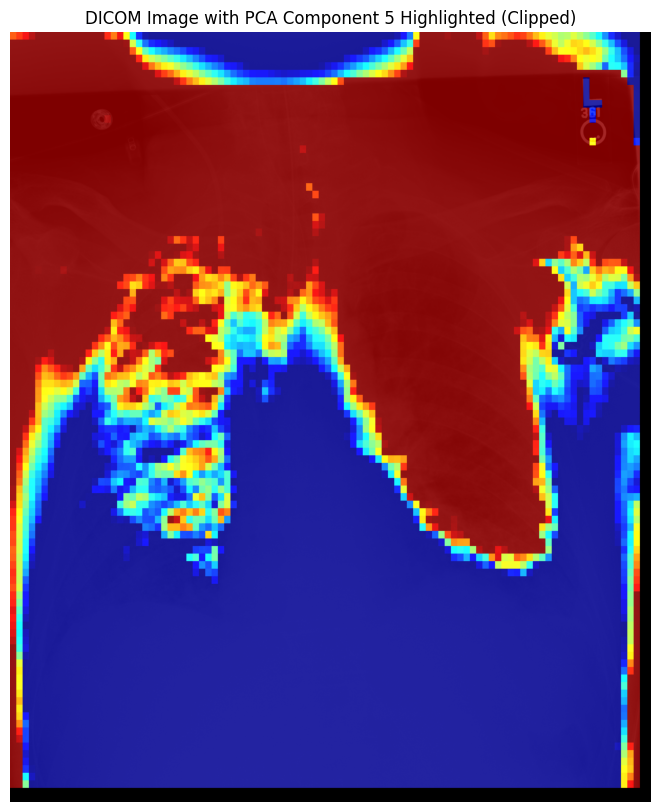

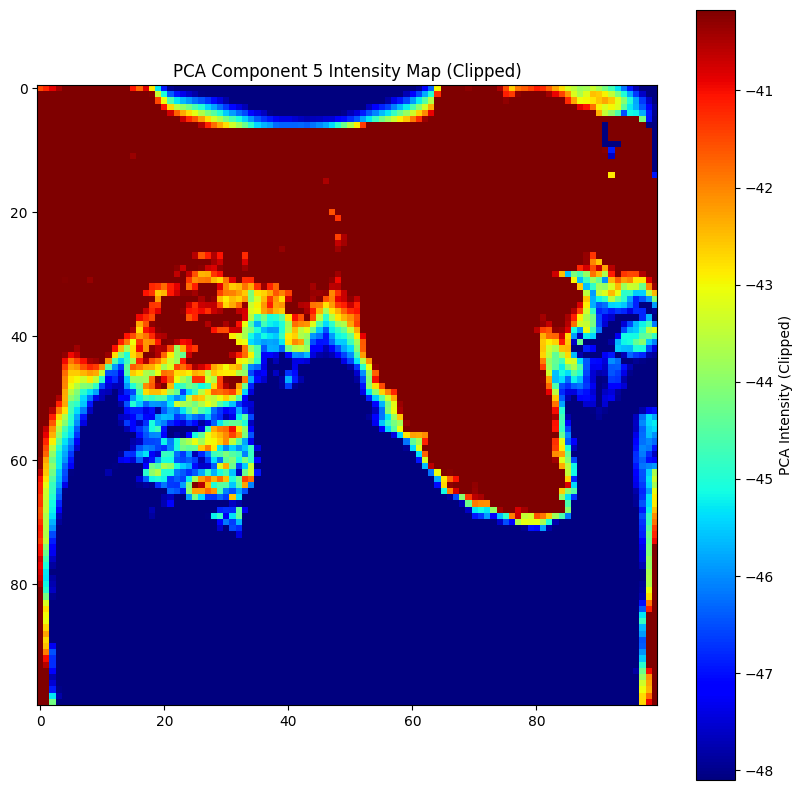

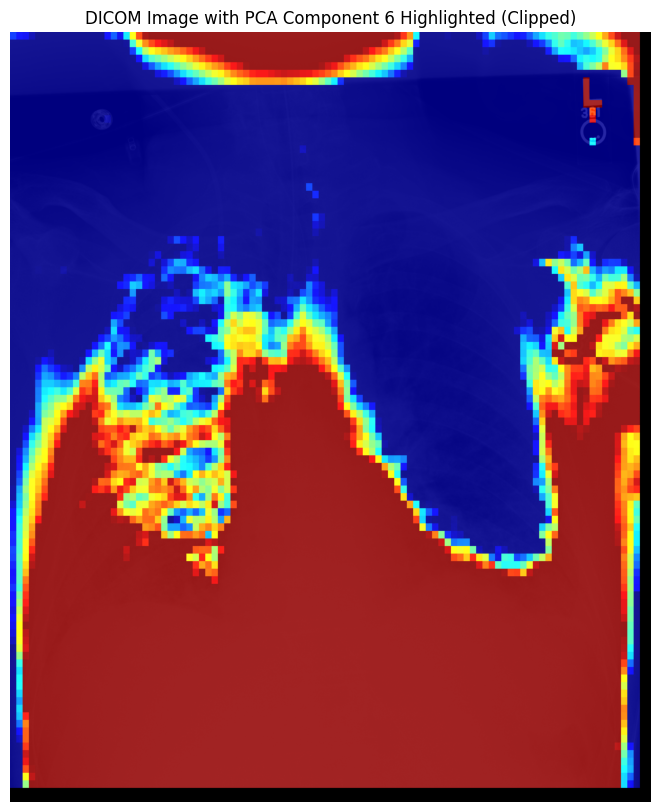

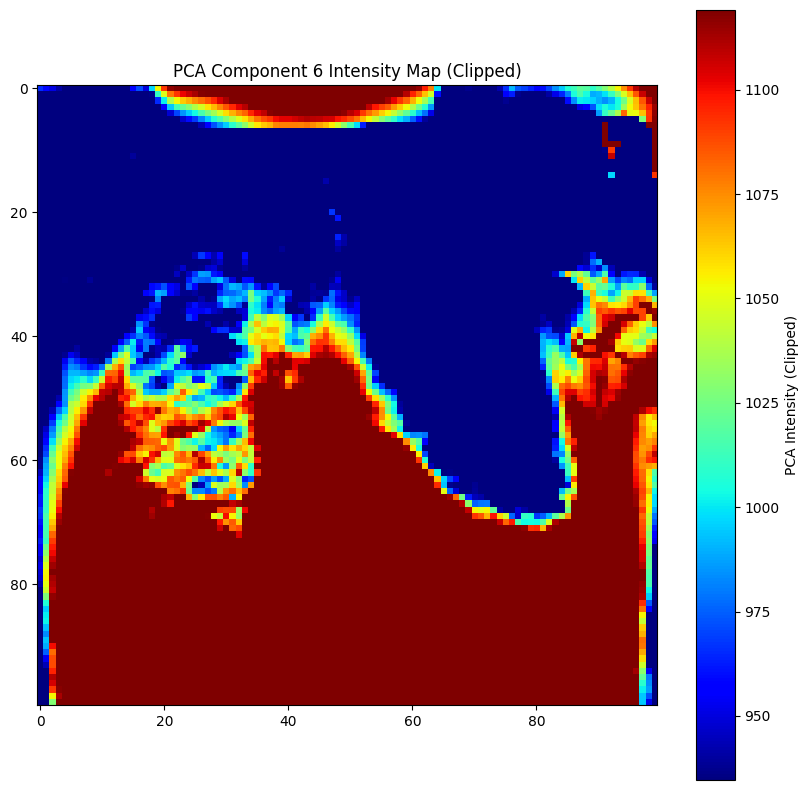

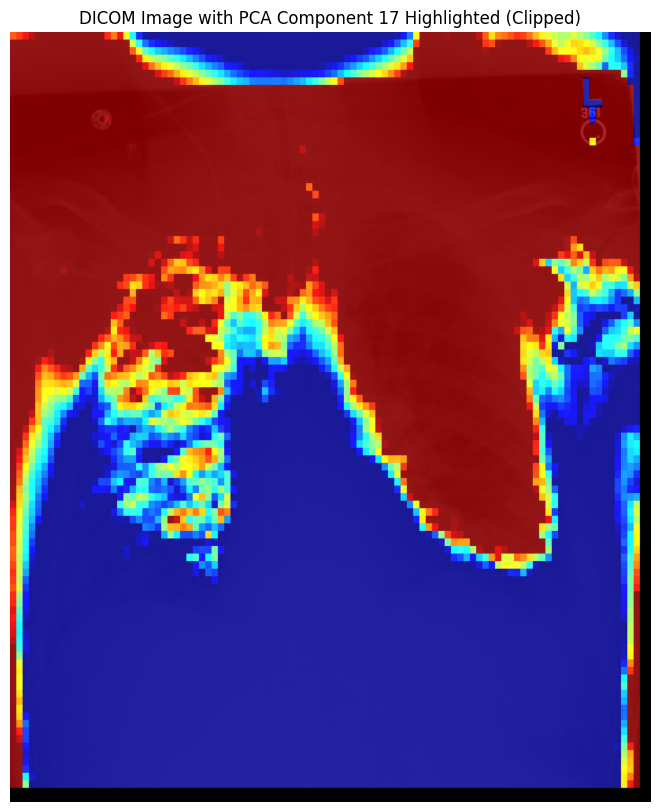

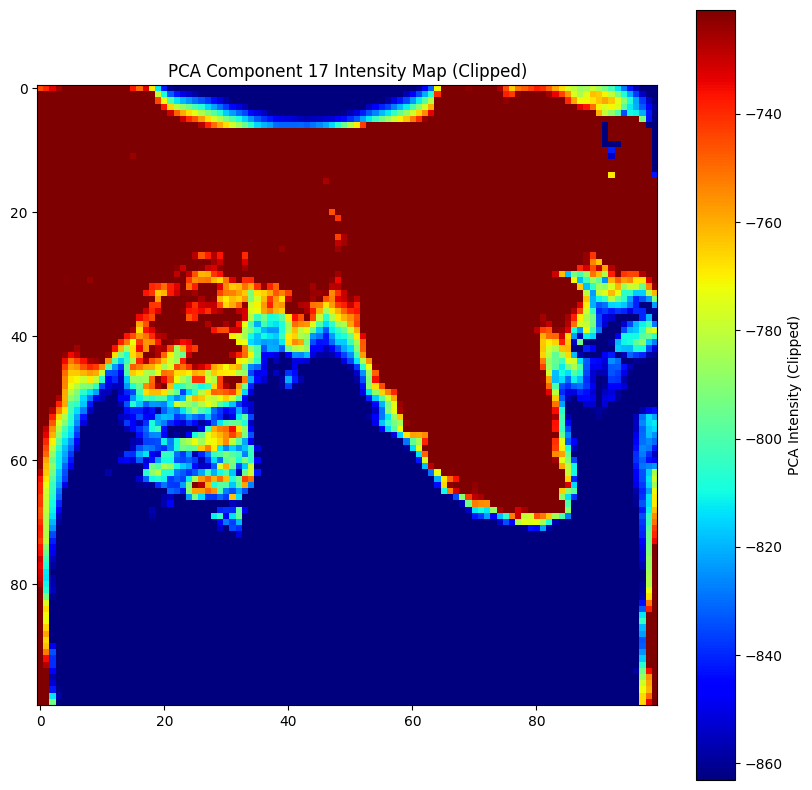

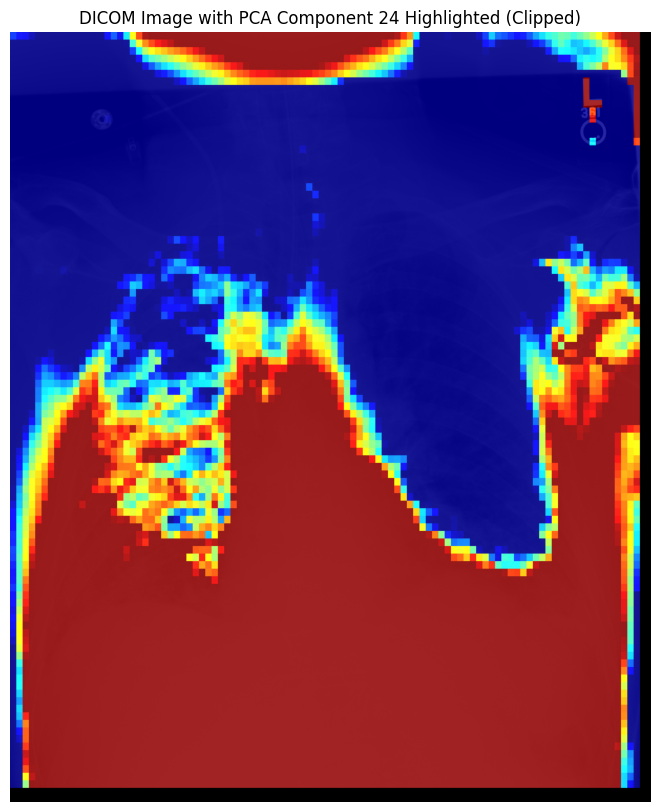

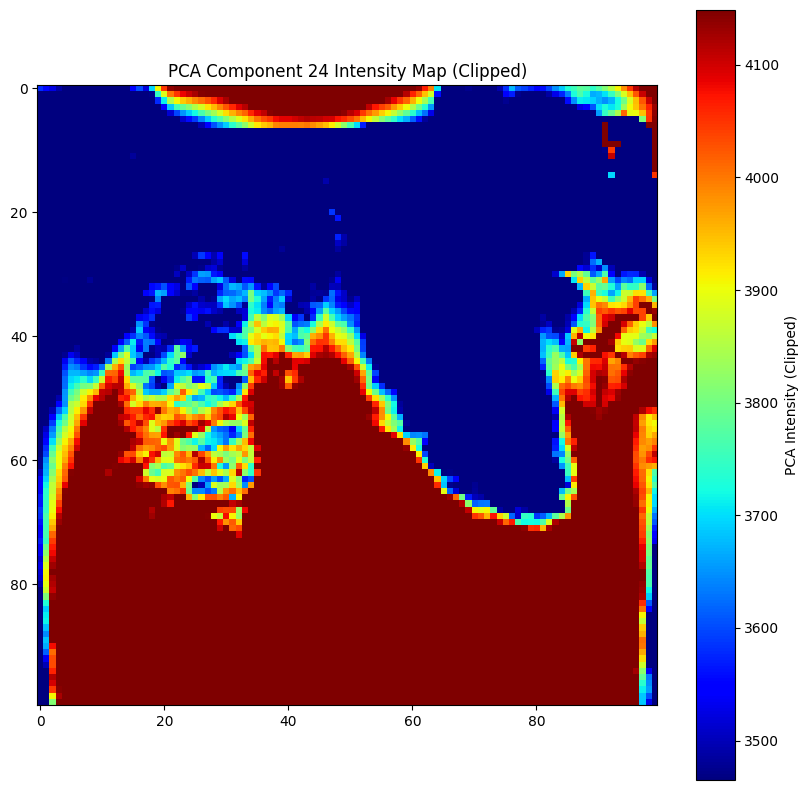

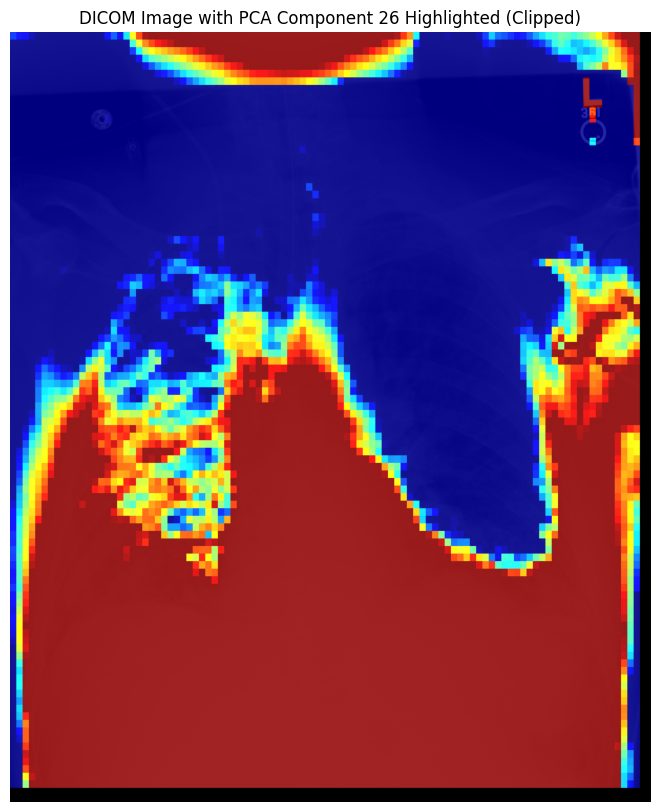

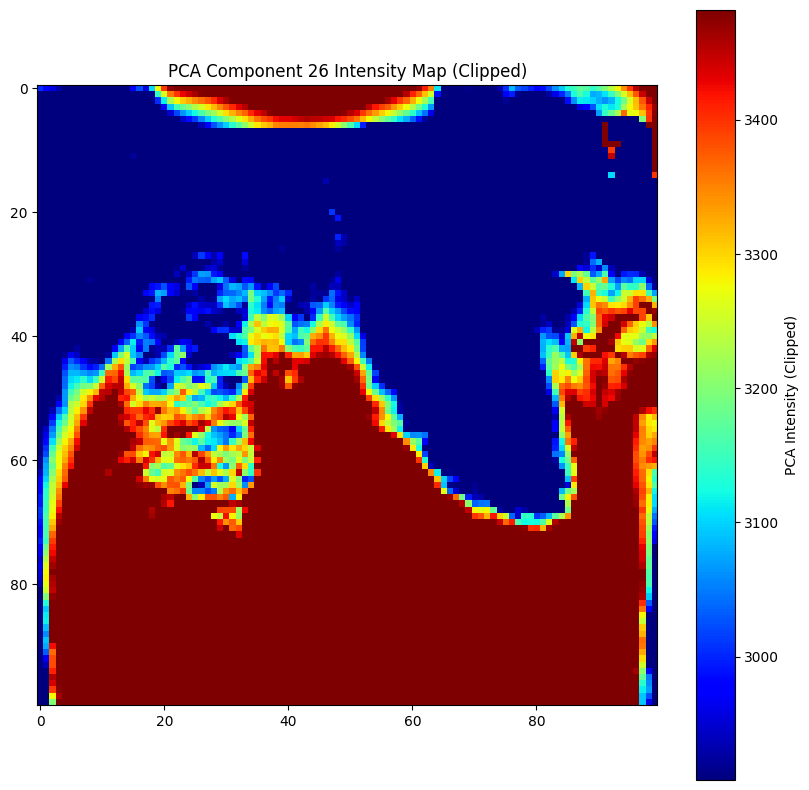

In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example3.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example3.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Function to parse TFRecord file
def _parse_function(proto):
    # Define your features
    keys_to_features = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }

    # Load one example
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    return parsed_features['embedding']

# Path to the TFRecord file
tfrecord_path = '/tmp/example3.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example3.tfrecord')
blob.download_to_filename(tfrecord_path)

# Create a dataset from the TFRecord file
dataset = tf.data.TFRecordDataset([tfrecord_path])
dataset = dataset.map(_parse_function)

# Extract embeddings (assuming there's only one record in the file for simplicity)
for record in dataset.take(1):
    pca_features = record.numpy()

# Directly use significant components from regression analysis
significant_components = [5, 6, 17, 24, 26]  # Ensure these are within the range of pca_features

# Define ROIs (divide the image into a 40x40 grid)
height, width = image_array.shape
num_rois = 100
roi_height, roi_width = height // num_rois, width // num_rois

rois = [
    (slice(i * roi_height, (i + 1) * roi_height), slice(j * roi_width, (j + 1) * roi_width))
    for i in range(num_rois) for j in range(num_rois)
]

for component in significant_components:
    if component - 1 >= len(pca_features):
        print(f"Component {component} is out of bounds for PCA features with length {len(pca_features)}")
        continue

    # Create an empty mask for the full image
    intensity_map = np.zeros((num_rois, num_rois))

    # Calculate PCA intensities for each ROI and store them in the intensity map
    for i, roi in enumerate(rois):
        pca_feature = pca_features[component - 1]

        # Extract the region from the DICOM image
        roi_image = image_array[roi]

        # Calculate the mean intensity of the PCA feature within this ROI
        pca_intensity = np.mean(roi_image) * pca_feature

        intensity_map[i // num_rois, i % num_rois] = pca_intensity

    # Normalize the intensity map for color mapping
    intensity_map_normalized = (intensity_map - np.min(intensity_map)) / (np.max(intensity_map) - np.min(intensity_map))

    # Clip the upper 20% and lower 20% of the intensity values
    lower_bound = np.percentile(intensity_map, 40)
    upper_bound = np.percentile(intensity_map, 60)
    clipped_intensity_map = np.clip(intensity_map, lower_bound, upper_bound)
    clipped_intensity_map_normalized = (clipped_intensity_map - np.min(clipped_intensity_map)) / (np.max(clipped_intensity_map) - np.min(clipped_intensity_map))

    # Create the overlay image with a color map and transparency
    overlay_image = np.zeros((*image_array.shape, 3), dtype=np.float32)
    alpha = 0.99  # Transparency level

    for i, roi in enumerate(rois):
        intensity = clipped_intensity_map_normalized[i // num_rois, i % num_rois]
        color = plt.cm.jet(intensity)[:3]  # Use a colormap (e.g., 'jet') to get the color
        for j in range(3):  # Apply color to the RGB channels
            overlay_image[roi[0], roi[1], j] = (1 - alpha) * (image_array[roi] / 255) + alpha * color[j]

    # Display the overlay image
    plt.figure(figsize=(10, 10))
    plt.imshow(overlay_image)
    plt.title(f'DICOM Image with PCA Component {component} Highlighted (Clipped)')
    plt.axis('off')
    plt.show()

    # Display the intensity map for reference
    plt.figure(figsize=(10, 10))
    plt.imshow(clipped_intensity_map, cmap='jet')
    plt.colorbar(label='PCA Intensity (Clipped)')
    plt.title(f'PCA Component {component} Intensity Map (Clipped)')
    plt.show()

    # Print the intensity values for each ROI
    #for i, roi in enumerate(rois):
    #    print(f"ROI {roi}: Intensity: {clipped_intensity_map[i // num_rois, i % num_rois]}")


3958.1154720458976


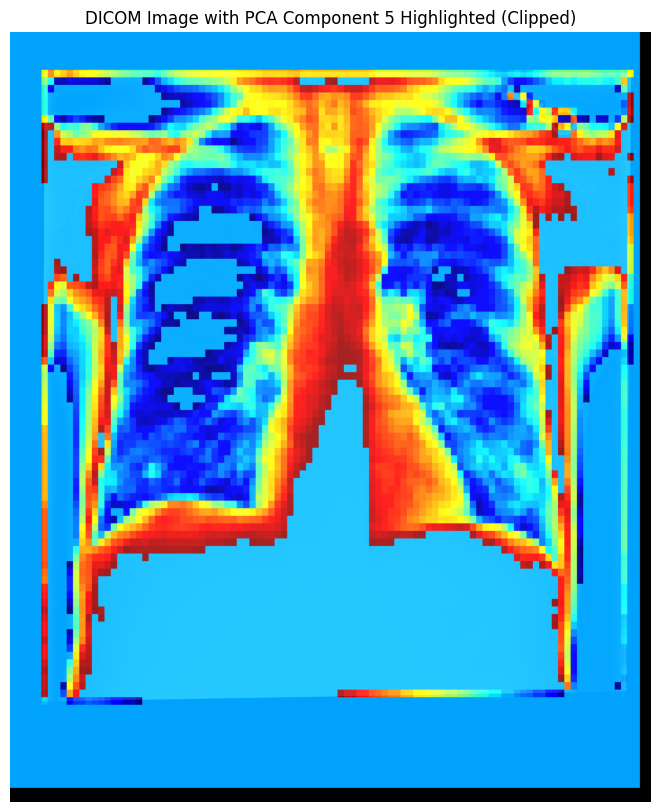

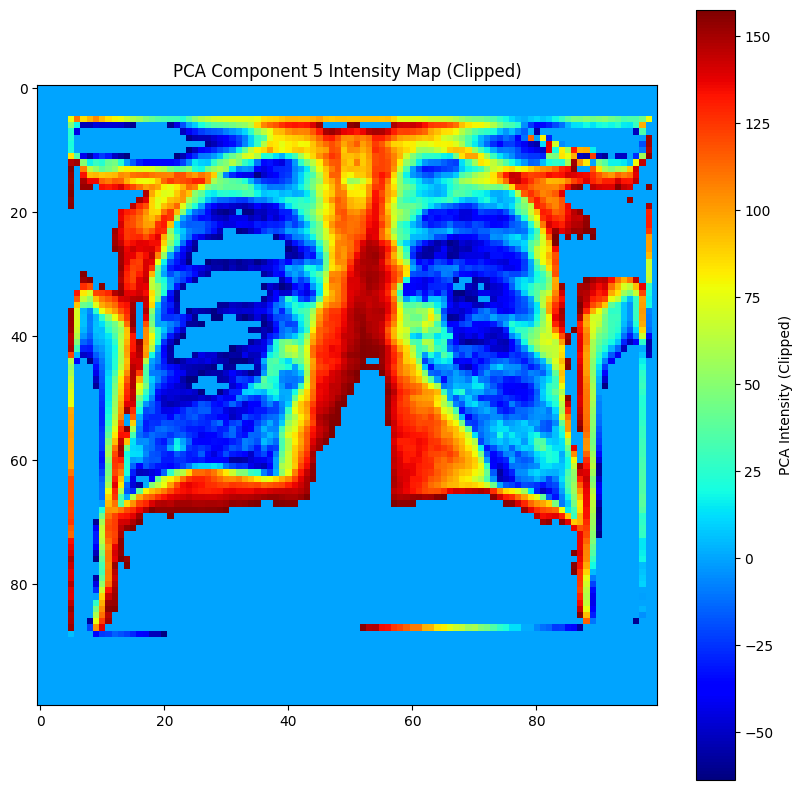

5289.328814232572


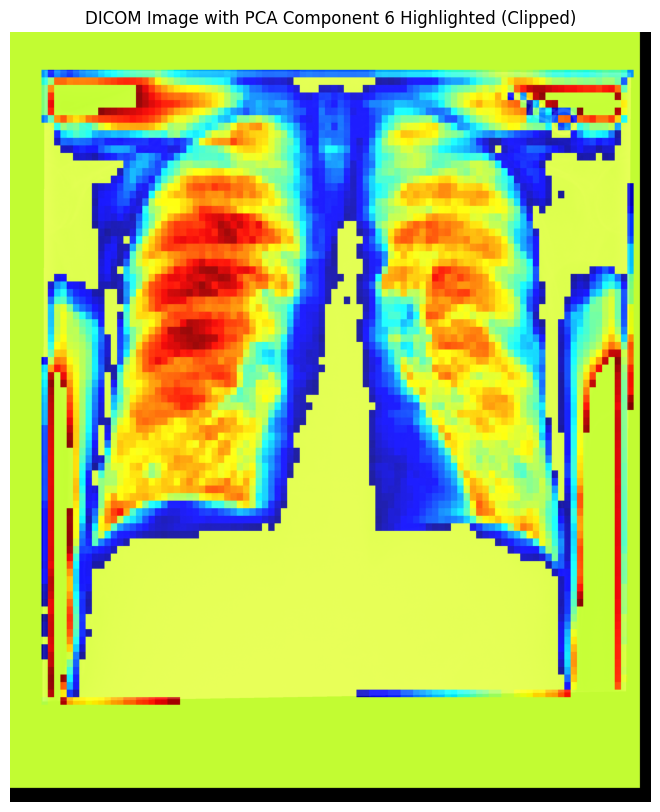

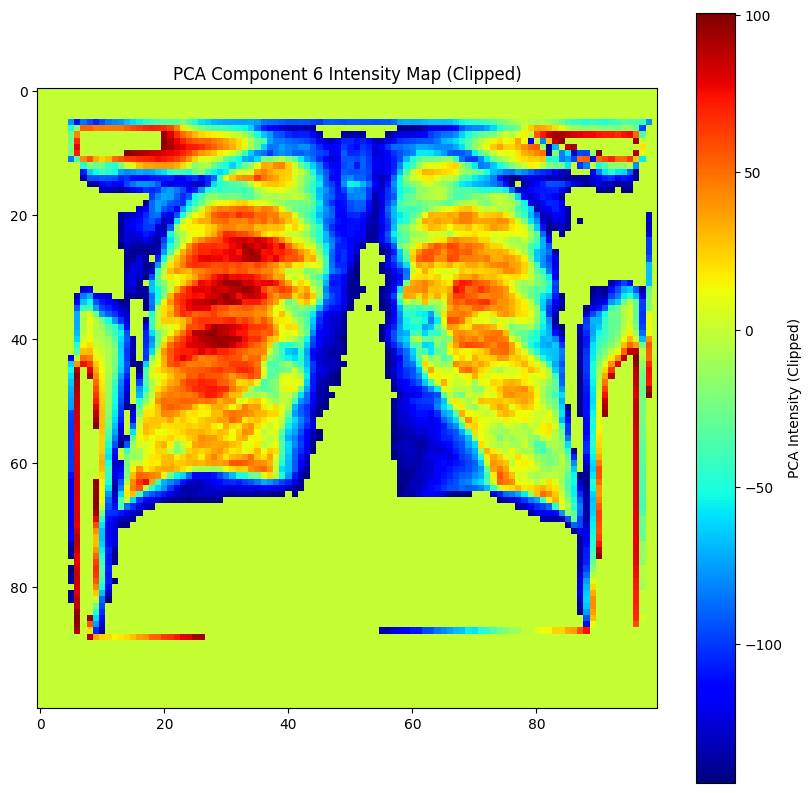

5289.328814232571


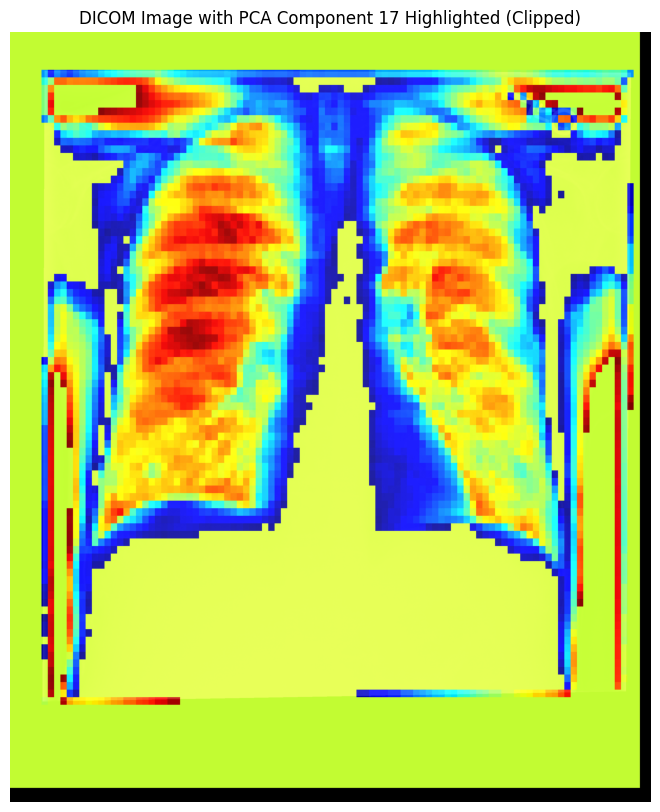

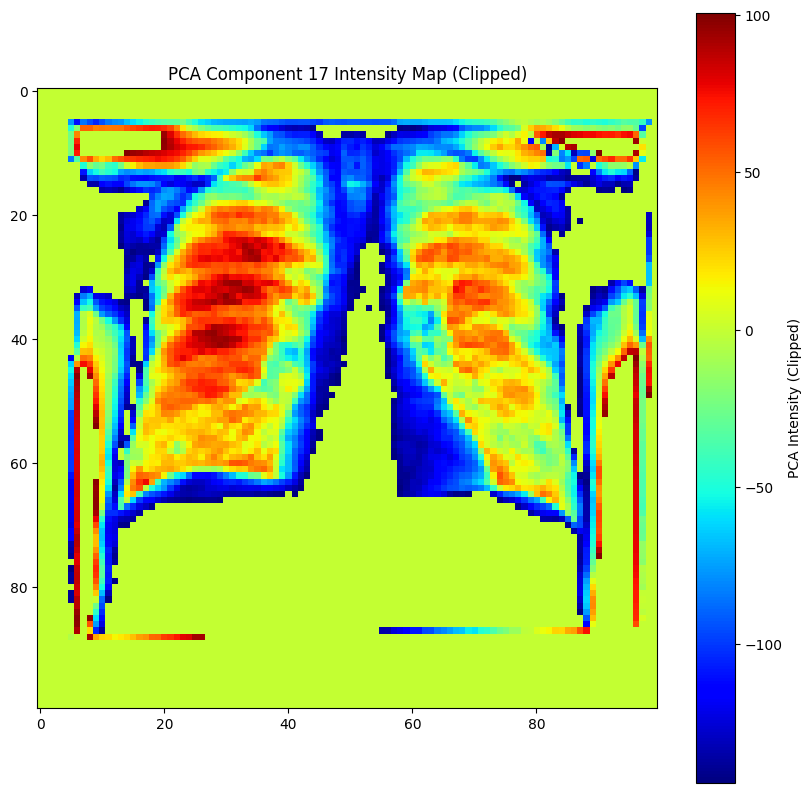

3958.1154720458962


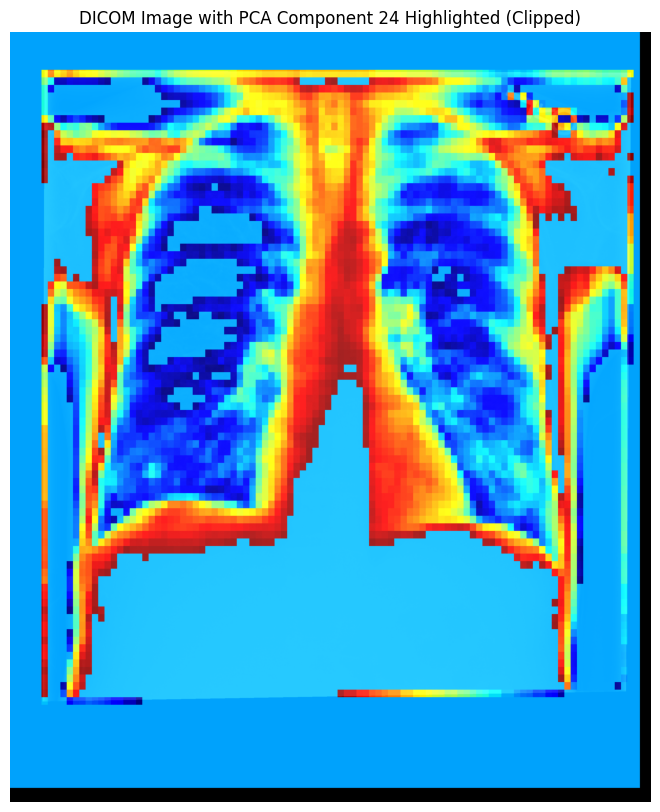

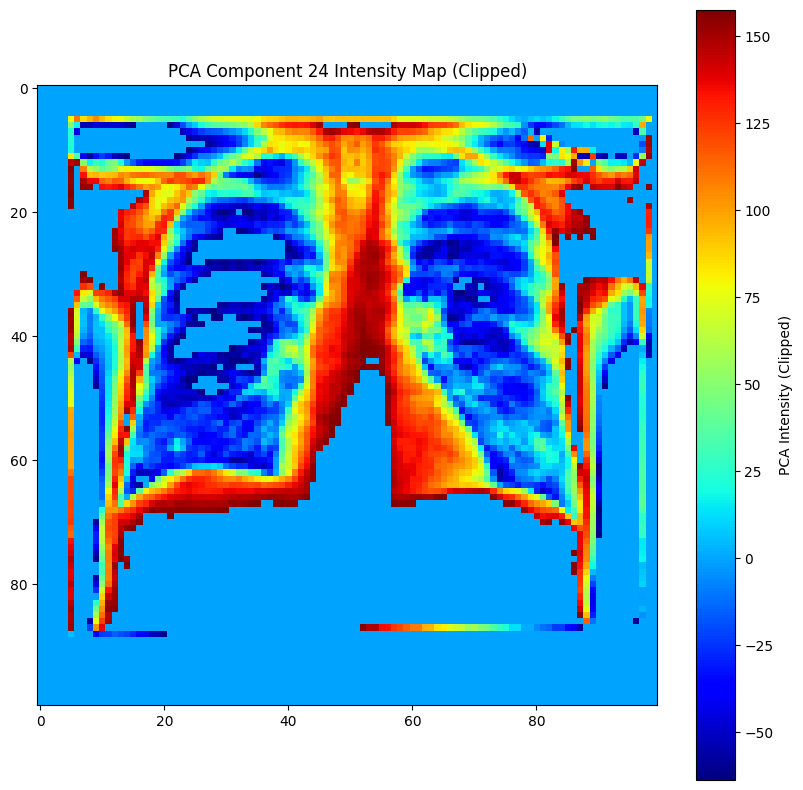

3958.1154720458967


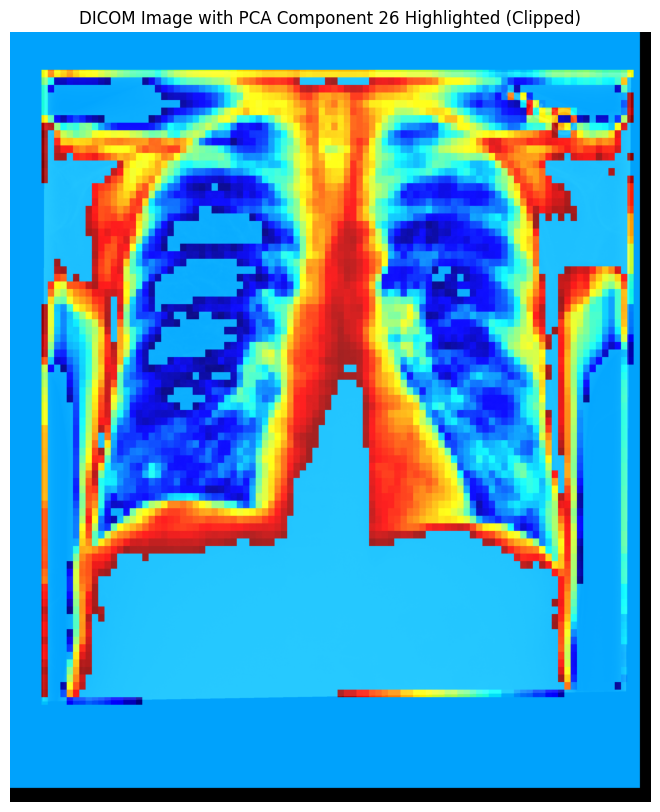

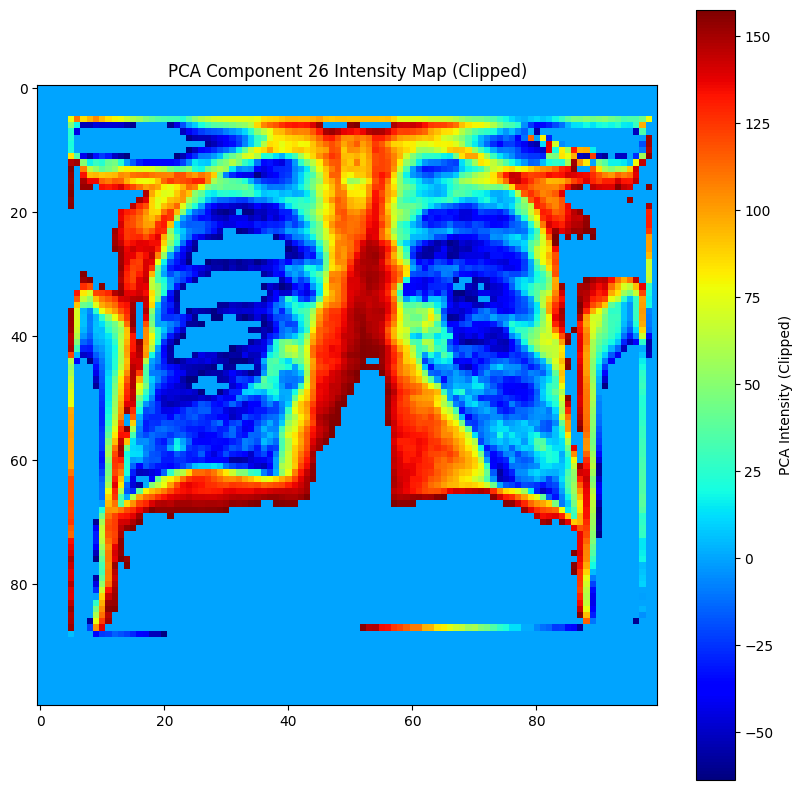

In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example1.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Function to parse TFRecord file
def _parse_function(proto):
    # Define your features
    keys_to_features = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }

    # Load one example
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    return parsed_features['embedding']

# Path to the TFRecord file
tfrecord_path = '/tmp/example1.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.tfrecord')
blob.download_to_filename(tfrecord_path)

# Create a dataset from the TFRecord file
dataset = tf.data.TFRecordDataset([tfrecord_path])
dataset = dataset.map(_parse_function)

# Extract embeddings (assuming there's only one record in the file for simplicity)
for record in dataset.take(1):
    pca_features = record.numpy()

# Directly use significant components from regression analysis
significant_components = [5, 6, 17, 24, 26]  # Ensure these are within the range of pca_features

# Define ROIs (divide the image into a 40x40 grid)
height, width = image_array.shape
num_rois = 100
roi_height, roi_width = height // num_rois, width // num_rois

rois = [
    (slice(i * roi_height, (i + 1) * roi_height), slice(j * roi_width, (j + 1) * roi_width))
    for i in range(num_rois) for j in range(num_rois)
]

for component in significant_components:
    if component - 1 >= len(pca_features):
        print(f"Component {component} is out of bounds for PCA features with length {len(pca_features)}")
        continue

    # Create an empty mask for the full image
    intensity_map = np.zeros((num_rois, num_rois))

    # Calculate PCA intensities for each ROI and store them in the intensity map
    for i, roi in enumerate(rois):
        pca_feature = pca_features[component - 1]

        # Extract the region from the DICOM image
        roi_image = image_array[roi]

        # Calculate the mean intensity of the PCA feature within this ROI
        pca_intensity = np.mean(roi_image) * pca_feature

        intensity_map[i // num_rois, i % num_rois] = pca_intensity

    # Normalize the intensity map to range 0 to 400
    intensity_map_normalized = MinMaxScaler(feature_range=(-200, 200)).fit_transform(intensity_map)

    # Determine the 20th and 80th percentiles
    lower_bound = np.percentile(intensity_map_normalized, 30)
    upper_bound = np.percentile(intensity_map_normalized, 80)

    # Clip values outside the bounds to 0
    clipped_intensity_map = np.where((intensity_map_normalized < lower_bound) | (intensity_map_normalized > upper_bound), 0, intensity_map_normalized)

    # Normalize the clipped intensity map for color mapping
    clipped_intensity_map_normalized = (clipped_intensity_map - np.min(clipped_intensity_map)) / (np.max(clipped_intensity_map) - np.min(clipped_intensity_map))
    print(np.sum(clipped_intensity_map_normalized))
    # Create the overlay image with a color map and transparency
    overlay_image = np.zeros((*image_array.shape, 3), dtype=np.float32)
    alpha = 0.99  # Transparency level

    for i, roi in enumerate(rois):
        intensity = clipped_intensity_map_normalized[i // num_rois, i % num_rois]
        color = plt.cm.jet(intensity)[:3]  # Use a colormap (e.g., 'jet') to get the color
        for j in range(3):  # Apply color to the RGB channels
            overlay_image[roi[0], roi[1], j] = (1 - alpha) * (image_array[roi] / 255) + alpha * color[j]

    # Display the overlay image
    plt.figure(figsize=(10, 10))
    plt.imshow(overlay_image)
    plt.title(f'DICOM Image with PCA Component {component} Highlighted (Clipped)')
    plt.axis('off')
    plt.show()

    # Display the intensity map for reference
    plt.figure(figsize=(10, 10))
    plt.imshow(clipped_intensity_map, cmap='jet')
    plt.colorbar(label='PCA Intensity (Clipped)')
    plt.title(f'PCA Component {component} Intensity Map (Clipped)')
    plt.show()

    # Print the intensity values for each ROI
    #for i, roi in enumerate(rois):
    #    print(f"ROI {roi}: Intensity: {clipped_intensity_map[i // num_rois, i % num_rois]}")


In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example2.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example2.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Function to parse TFRecord file
def _parse_function(proto):
    # Define your features
    keys_to_features = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }

    # Load one example
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    return parsed_features['embedding']

# Path to the TFRecord file
tfrecord_path = '/tmp/example2.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example2.tfrecord')
blob.download_to_filename(tfrecord_path)

# Create a dataset from the TFRecord file
dataset = tf.data.TFRecordDataset([tfrecord_path])
dataset = dataset.map(_parse_function)

# Extract embeddings (assuming there's only one record in the file for simplicity)
for record in dataset.take(1):
    pca_features = record.numpy()

# Directly use significant components from regression analysis
significant_components = [5, 6, 17, 24, 26]  # Ensure these are within the range of pca_features

# Define ROIs (divide the image into a 40x40 grid)
height, width = image_array.shape
num_rois = 100
roi_height, roi_width = height // num_rois, width // num_rois

rois = [
    (slice(i * roi_height, (i + 1) * roi_height), slice(j * roi_width, (j + 1) * roi_width))
    for i in range(num_rois) for j in range(num_rois)
]

for component in significant_components:
    if component - 1 >= len(pca_features):
        print(f"Component {component} is out of bounds for PCA features with length {len(pca_features)}")
        continue

    # Create an empty mask for the full image
    intensity_map = np.zeros((num_rois, num_rois))

    # Calculate PCA intensities for each ROI and store them in the intensity map
    for i, roi in enumerate(rois):
        pca_feature = pca_features[component - 1]

        # Extract the region from the DICOM image
        roi_image = image_array[roi]

        # Calculate the mean intensity of the PCA feature within this ROI
        pca_intensity = np.mean(roi_image) * pca_feature

        intensity_map[i // num_rois, i % num_rois] = pca_intensity

    # Normalize the intensity map to range 0 to 400
    intensity_map_normalized = MinMaxScaler(feature_range=(-200, 200)).fit_transform(intensity_map)

    # Determine the 20th and 80th percentiles
    lower_bound = np.percentile(intensity_map_normalized, 30)
    upper_bound = np.percentile(intensity_map_normalized, 90)

    # Clip values outside the bounds to 0
    clipped_intensity_map = np.where((intensity_map_normalized < lower_bound) | (intensity_map_normalized > upper_bound), 0, intensity_map_normalized)

    # Normalize the clipped intensity map for color mapping
    clipped_intensity_map_normalized = (clipped_intensity_map - np.min(clipped_intensity_map)) / (np.max(clipped_intensity_map) - np.min(clipped_intensity_map))
    print(np.sum(clipped_intensity_map_normalized))
    # Create the overlay image with a color map and transparency
    overlay_image = np.zeros((*image_array.shape, 3), dtype=np.float32)
    alpha = 0.99  # Transparency level

    for i, roi in enumerate(rois):
        intensity = clipped_intensity_map_normalized[i // num_rois, i % num_rois]
        color = plt.cm.jet(intensity)[:3]  # Use a colormap (e.g., 'jet') to get the color
        for j in range(3):  # Apply color to the RGB channels
            overlay_image[roi[0], roi[1], j] = (1 - alpha) * (image_array[roi] / 255) + alpha * color[j]

    # Display the overlay image
    plt.figure(figsize=(10, 10))
    plt.imshow(overlay_image)
    plt.title(f'DICOM Image with PCA Component {component} Highlighted (Clipped)')
    plt.axis('off')
    plt.show()

    # Display the intensity map for reference
    plt.figure(figsize=(10, 10))
    plt.imshow(clipped_intensity_map, cmap='jet')
    plt.colorbar(label='PCA Intensity (Clipped)')
    plt.title(f'PCA Component {component} Intensity Map (Clipped)')
    plt.show()

    # Print the intensity values for each ROI
    #for i, roi in enumerate(rois):
    #    print(f"ROI {roi}: Intensity: {clipped_intensity_map[i // num_rois, i % num_rois]}")


Output hidden; open in https://colab.research.google.com to view.

5534.543600229332


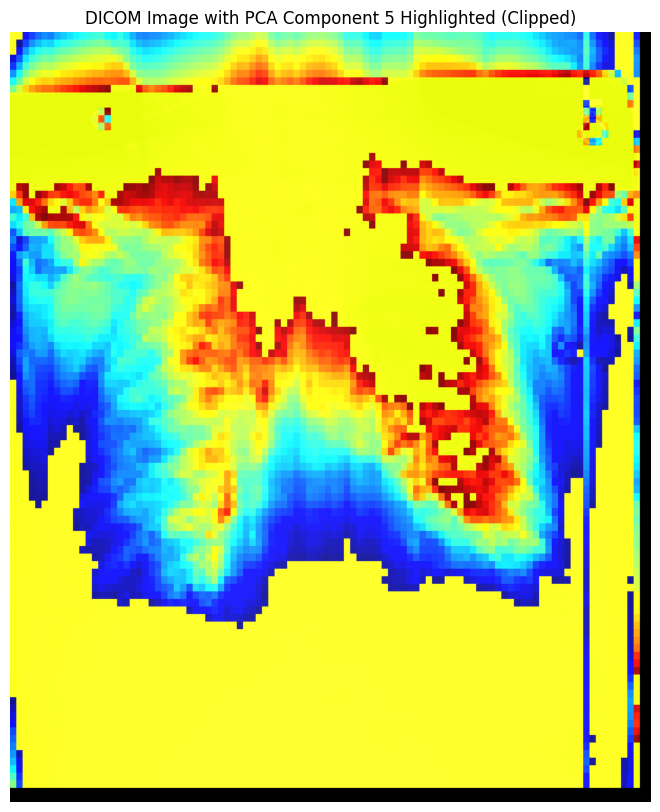

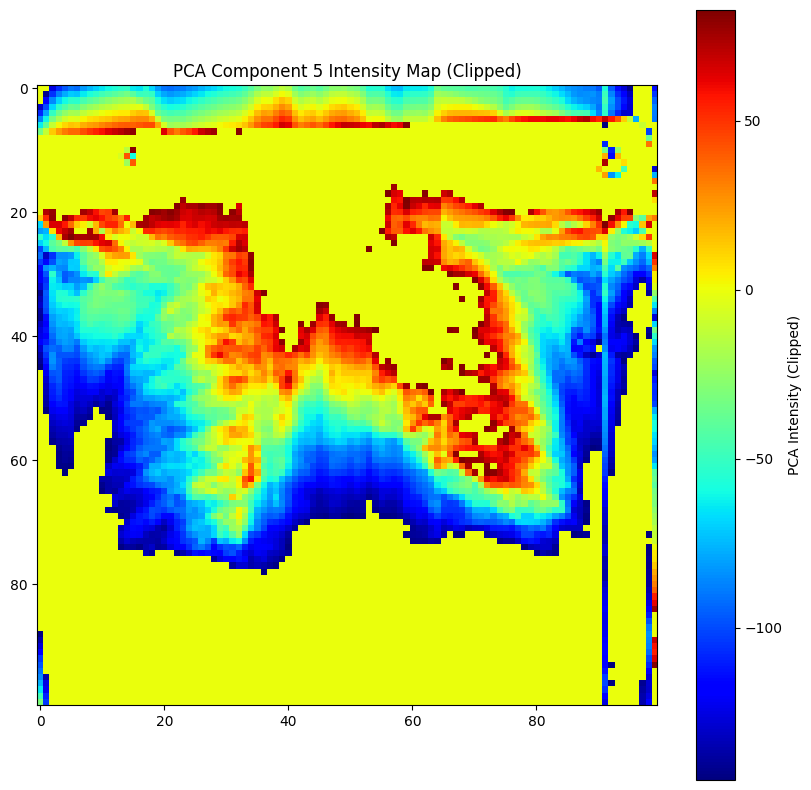

3225.0028356005705


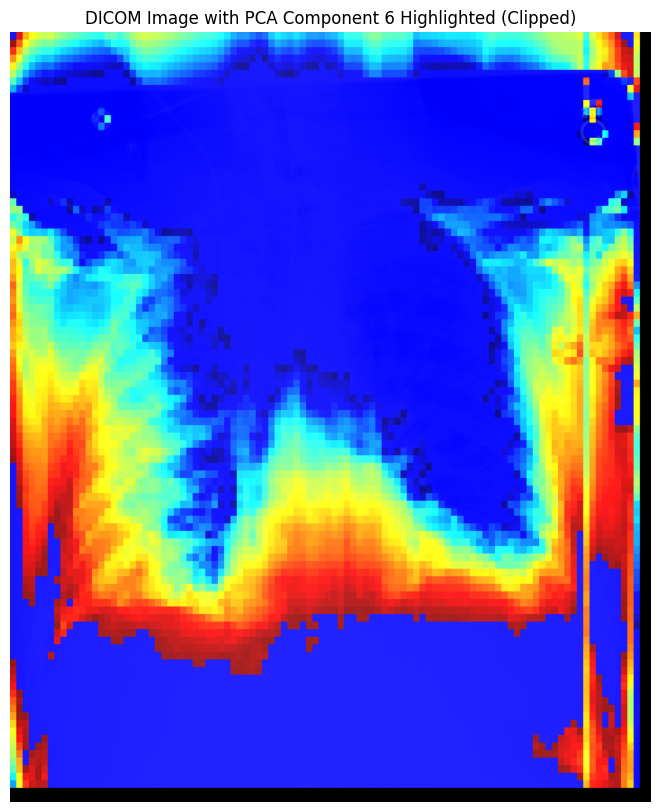

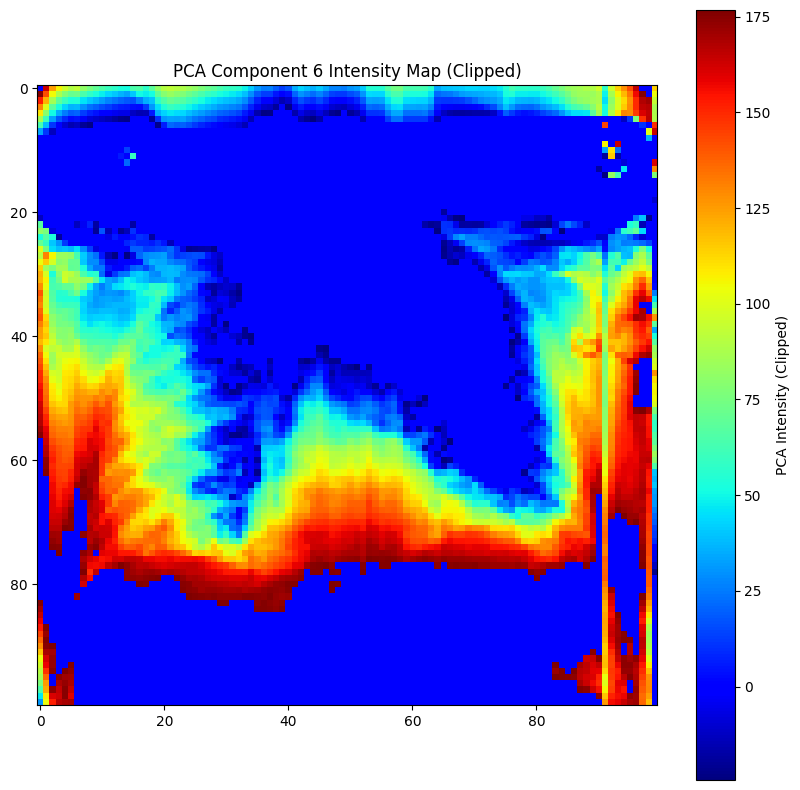

5534.543600229329


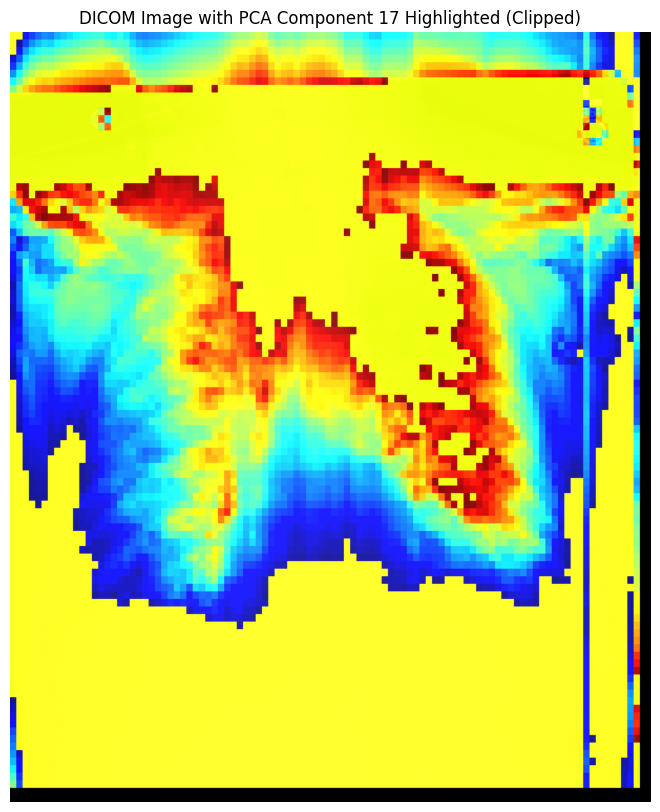

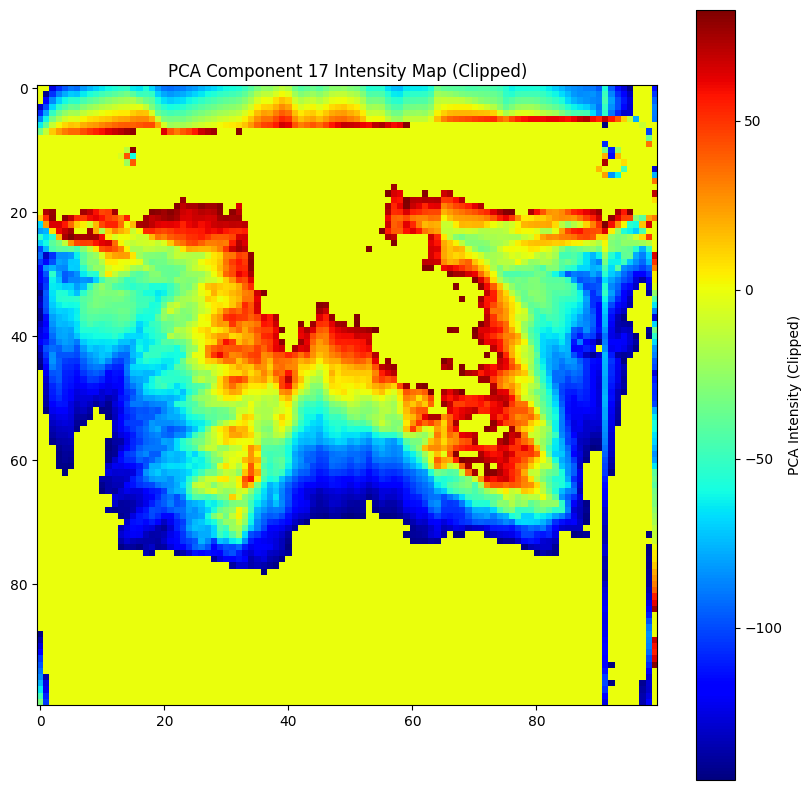

3225.002835600571


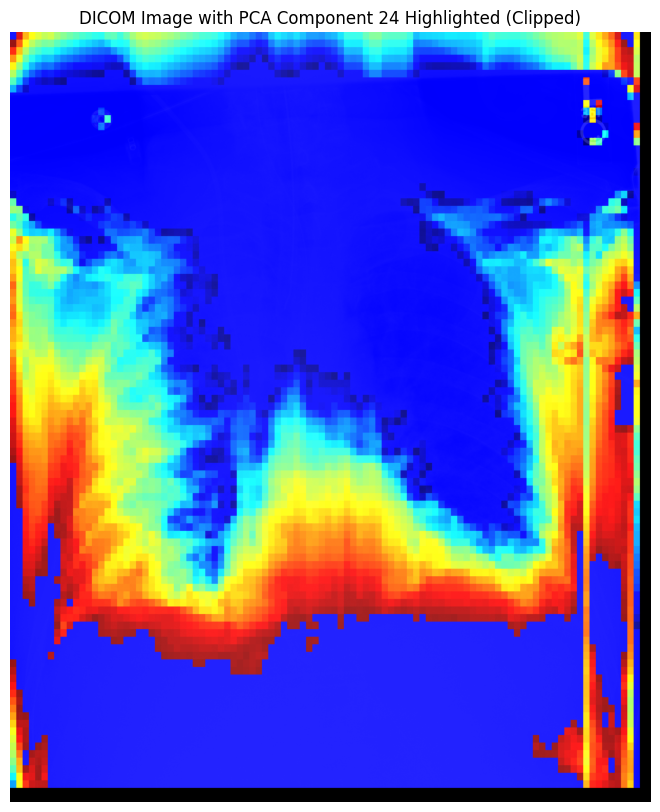

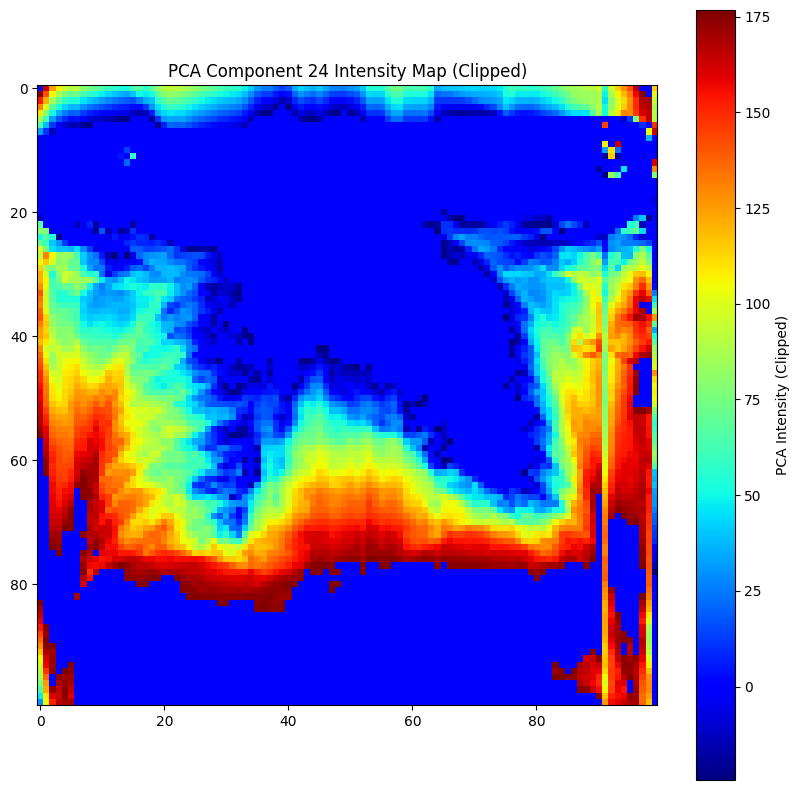

3225.002835600571


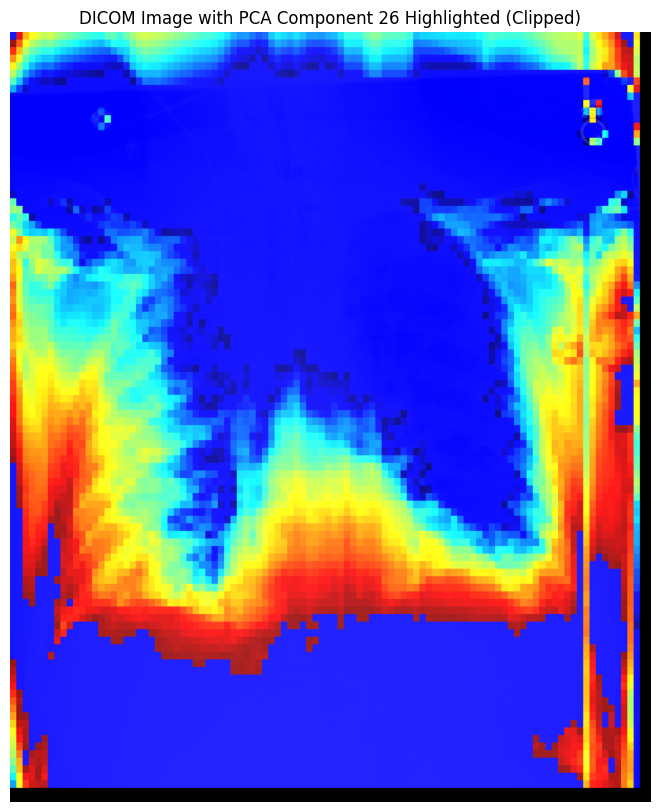

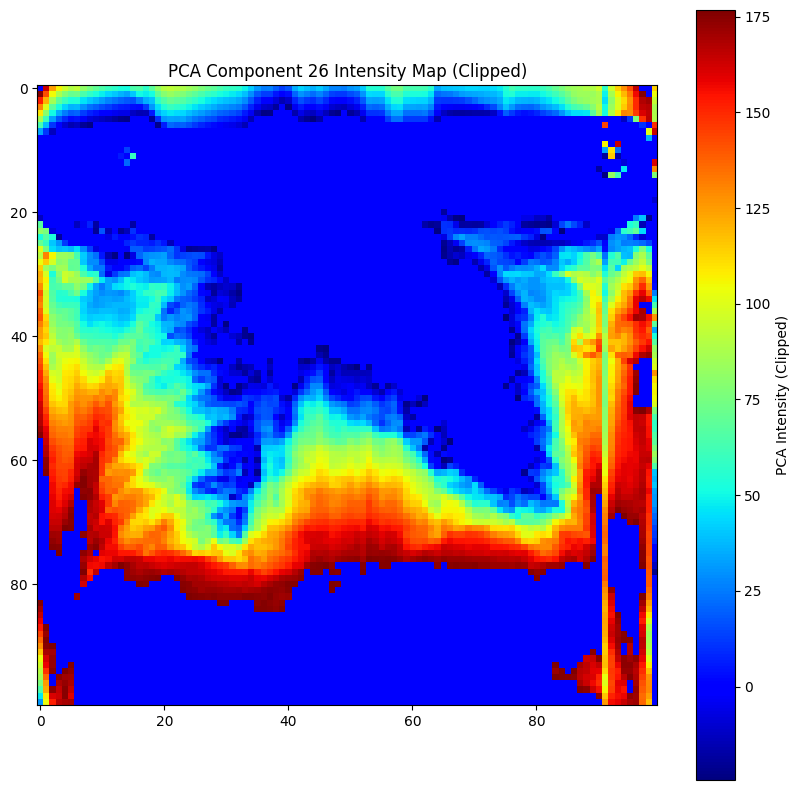

In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example3.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example3.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Function to parse TFRecord file
def _parse_function(proto):
    # Define your features
    keys_to_features = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }

    # Load one example
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    return parsed_features['embedding']

# Path to the TFRecord file
tfrecord_path = '/tmp/example3.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example3.tfrecord')
blob.download_to_filename(tfrecord_path)

# Create a dataset from the TFRecord file
dataset = tf.data.TFRecordDataset([tfrecord_path])
dataset = dataset.map(_parse_function)

# Extract embeddings (assuming there's only one record in the file for simplicity)
for record in dataset.take(1):
    pca_features = record.numpy()

# Directly use significant components from regression analysis
significant_components = [5, 6, 17, 24, 26]  # Ensure these are within the range of pca_features

# Define ROIs (divide the image into a 40x40 grid)
height, width = image_array.shape
num_rois = 100
roi_height, roi_width = height // num_rois, width // num_rois

rois = [
    (slice(i * roi_height, (i + 1) * roi_height), slice(j * roi_width, (j + 1) * roi_width))
    for i in range(num_rois) for j in range(num_rois)
]

for component in significant_components:
    if component - 1 >= len(pca_features):
        print(f"Component {component} is out of bounds for PCA features with length {len(pca_features)}")
        continue

    # Create an empty mask for the full image
    intensity_map = np.zeros((num_rois, num_rois))

    # Calculate PCA intensities for each ROI and store them in the intensity map
    for i, roi in enumerate(rois):
        pca_feature = pca_features[component - 1]

        # Extract the region from the DICOM image
        roi_image = image_array[roi]

        # Calculate the mean intensity of the PCA feature within this ROI
        pca_intensity = np.mean(roi_image) * pca_feature

        intensity_map[i // num_rois, i % num_rois] = pca_intensity

    # Normalize the intensity map to range 0 to 400
    intensity_map_normalized = MinMaxScaler(feature_range=(-200, 200)).fit_transform(intensity_map)

    # Determine the 20th and 80th percentiles
    lower_bound = np.percentile(intensity_map_normalized, 30)
    upper_bound = np.percentile(intensity_map_normalized, 80)

    # Clip values outside the bounds to 0
    clipped_intensity_map = np.where((intensity_map_normalized < lower_bound) | (intensity_map_normalized > upper_bound), 0, intensity_map_normalized)

    # Normalize the clipped intensity map for color mapping
    clipped_intensity_map_normalized = (clipped_intensity_map - np.min(clipped_intensity_map)) / (np.max(clipped_intensity_map) - np.min(clipped_intensity_map))
    print(np.sum(clipped_intensity_map_normalized))
    # Create the overlay image with a color map and transparency
    overlay_image = np.zeros((*image_array.shape, 3), dtype=np.float32)
    alpha = 0.99  # Transparency level

    for i, roi in enumerate(rois):
        intensity = clipped_intensity_map_normalized[i // num_rois, i % num_rois]
        color = plt.cm.jet(intensity)[:3]  # Use a colormap (e.g., 'jet') to get the color
        for j in range(3):  # Apply color to the RGB channels
            overlay_image[roi[0], roi[1], j] = (1 - alpha) * (image_array[roi] / 255) + alpha * color[j]

    # Display the overlay image
    plt.figure(figsize=(10, 10))
    plt.imshow(overlay_image)
    plt.title(f'DICOM Image with PCA Component {component} Highlighted (Clipped)')
    plt.axis('off')
    plt.show()

    # Display the intensity map for reference
    plt.figure(figsize=(10, 10))
    plt.imshow(clipped_intensity_map, cmap='jet')
    plt.colorbar(label='PCA Intensity (Clipped)')
    plt.title(f'PCA Component {component} Intensity Map (Clipped)')
    plt.show()

    # Print the intensity values for each ROI
    #for i, roi in enumerate(rois):
    #    print(f"ROI {roi}: Intensity: {clipped_intensity_map[i // num_rois, i % num_rois]}")


# Random forest regressor with peep

Significant Components (P-Value < 0.1):
5      pca_6
16    pca_17
20    pca_21
23    pca_24
25    pca_26
26    pca_27
37    pca_38
47    pca_48
Name: PCA Component, dtype: object
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=10, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.9s
[CV] END max_depth=10, max_features=N

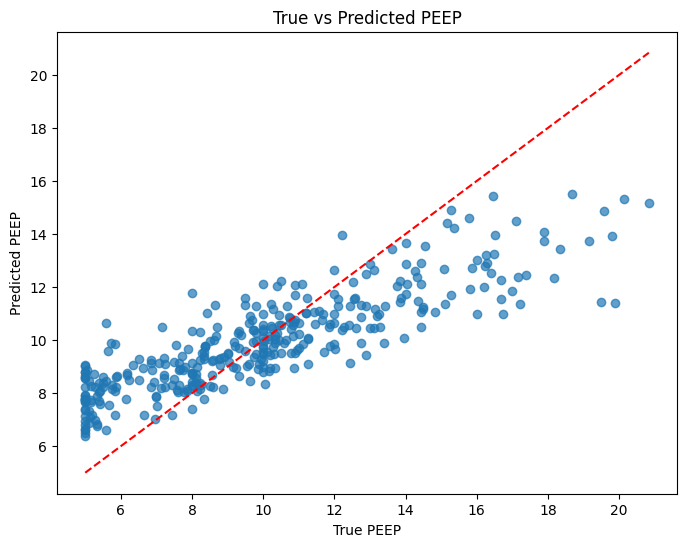

In [16]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

# Convert results to DataFrame
results_df = pd.DataFrame(results_list)

# Filter significant components based on p-value < 0.1
significant_components = results_df[results_df['P-Value'] < 0.1]['PCA Component']
print("Significant Components (P-Value < 0.1):")
print(significant_components)

# Prepare data with significant components for multivariate regression
X_significant = df[significant_components]

# Define the model
rf = RandomForestRegressor(random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': [None, 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform the grid search with n_jobs=1
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=1, verbose=2)
grid_search.fit(X_significant, y)

# Output the best parameters
print("Best parameters found: ", grid_search.best_params_)

# Train the final model with the best parameters
best_rf = grid_search.best_estimator_

# Predict on the same dataset
y_pred = best_rf.predict(X_significant)

# Calculate R-squared value
r2 = r2_score(y, y_pred)
print(f"R-squared value: {r2}")

# Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculate Mean Absolute Error
mae = mean_absolute_error(y, y_pred)
print(f"Mean Absolute Error: {mae}")

# Calculate variance of the residuals (prediction errors)
variance = np.var(y_pred - y)
print(f"Variance: {variance}")

# Optionally, visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.xlabel('True PEEP')
plt.ylabel('Predicted PEEP')
plt.title('True vs Predicted PEEP')
plt.show()


In [70]:
# Calculate residuals
residuals = np.abs(y_test - y_pred)

# Find the indices of the top 3 largest residuals
top_3_indices = np.argsort(residuals)[-3:]

# Output the raw data for these points
raw_data_indices = X_test.iloc[top_3_indices].index
raw_data = df.loc[raw_data_indices]

# Display the raw data
print("Raw data for the 3 data points that are the most off-prediction:")
print(raw_data)

Raw data for the 3 data points that are the most off-prediction:
     study_id  subject_id           study_datetime  \
55   58013302    11360891  2173-05-25 12:52:07.046   
137  56574538    13600861  2120-07-11 05:07:10.670   
30   56074012    10745072  2150-11-18 04:47:28.170   

                                  path  \
55   files/p11/p11360891/s58013302.txt   
137  files/p13/p13600861/s56574538.txt   
30   files/p10/p10745072/s56074012.txt   

                                         dicom_id             timezero  \
55   ec5c87f2-4ba0b3ce-5e12b1f6-88e9b480-90b2d494  2173-05-25 10:19:00   
137  106cd8e3-a7d91453-5ae84bdc-e797402f-16e0e876  2120-07-11 07:19:00   
30   2fd1e5d8-712dc8b9-5d2552dc-36e64ec0-4d826f76  2150-11-18 00:31:00   

     icu_mort   avg_peep                 time_diff  embedding_0  ...  \
55          0  17.166667    0 days 02:33:07.046000    -0.013457  ...   
137         0   5.000000  -1 days +21:48:10.670000    -1.255207  ...   
30          1  16.666667    0 days 0

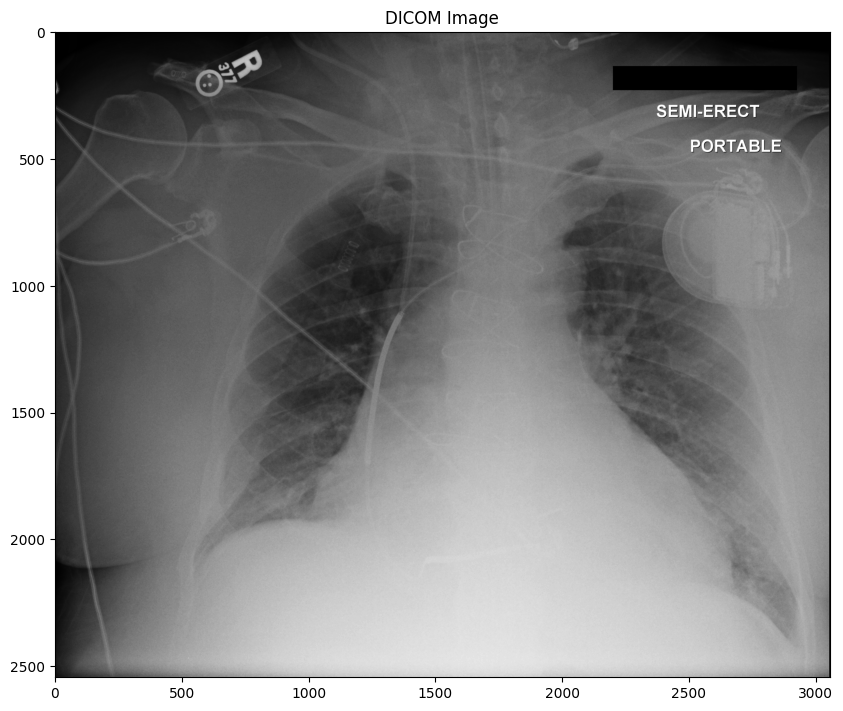

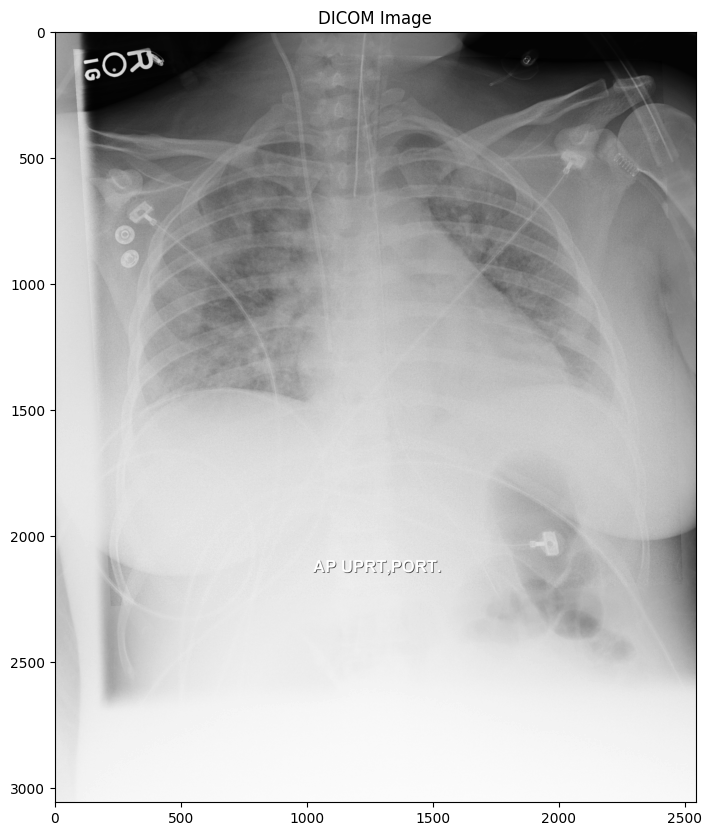

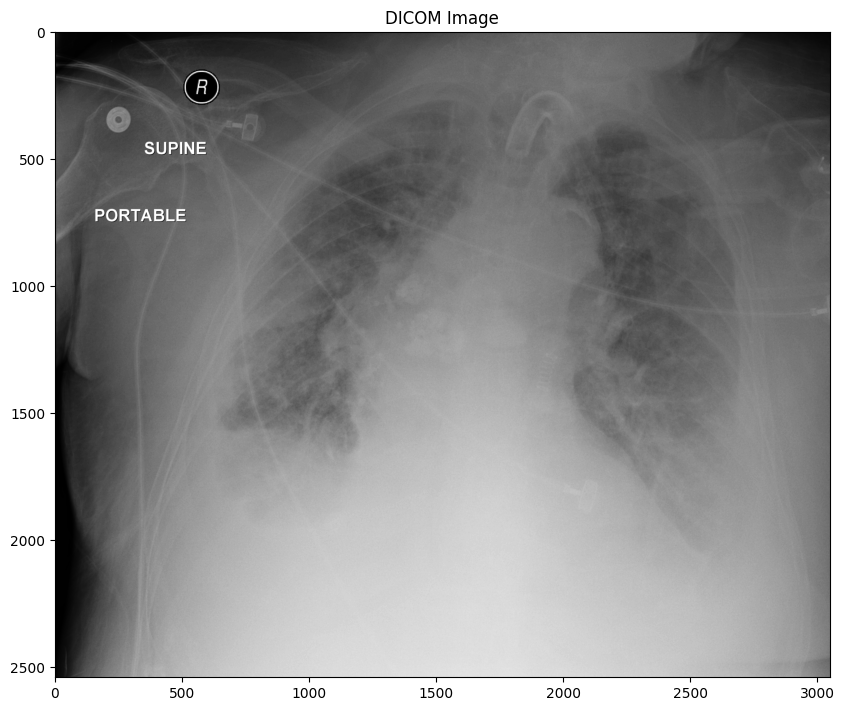

In [74]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Path to the DICOM file
dicom_path = '/tmp/example1.dcm'

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Download the DICOM file from the GCP bucket
blob = bucket.blob('prediction_datas/incorrect_predictions/X4.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()
# Download the DICOM file from the GCP bucket
blob = bucket.blob('prediction_datas/incorrect_predictions/X5.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

# Download the DICOM file from the GCP bucket
blob = bucket.blob('prediction_datas/incorrect_predictions/X6.dcm')
blob.download_to_filename(dicom_path)
# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

# Linear regression with peep

Significant Components (P-Value < 0.1):
2      pca_3
4      pca_5
5      pca_6
16    pca_17
20    pca_21
23    pca_24
25    pca_26
26    pca_27
36    pca_37
Name: PCA Component, dtype: object
R-squared value: 0.205684225042424
Mean Squared Error: 9.40008186746687
Mean Absolute Error: 2.2636787096563733
Variance: 9.370731086064573


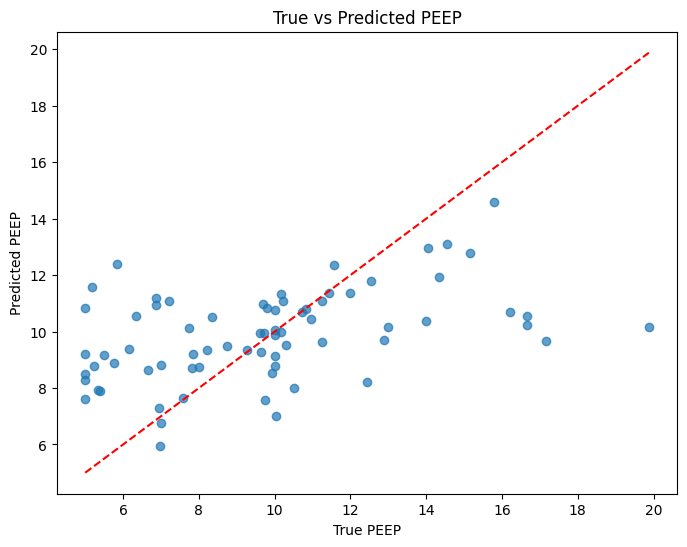

In [21]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm

# Convert results to DataFrame
results_df = pd.DataFrame(results_list)

# Filter significant components based on p-value < 0.1
significant_components = results_df[results_df['P-Value'] < 0.1]['PCA Component']
print("Significant Components (P-Value < 0.1):")
print(significant_components)

# Prepare data with significant components for multivariate regression
X_significant = df[significant_components]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_significant, y, test_size=0.2, random_state=42)

# Train a multivariate linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate R-squared value
r2 = r2_score(y_test, y_pred)
print(f"R-squared value: {r2}")

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

# Calculate variance of the residuals (prediction errors)
variance = np.var(y_pred - y_test)
print(f"Variance: {variance}")

# Optionally, visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('True PEEP')
plt.ylabel('Predicted PEEP')
plt.title('True vs Predicted PEEP')
plt.show()


Significant Components (P-Value < 0.1):
5      pca_6
16    pca_17
20    pca_21
23    pca_24
25    pca_26
26    pca_27
37    pca_38
Name: PCA Component, dtype: object
R-squared value: 0.24218640036559935
Mean Squared Error: 9.956476583147325
Mean Absolute Error: 2.514659530905944
Variance: 9.956476583147323


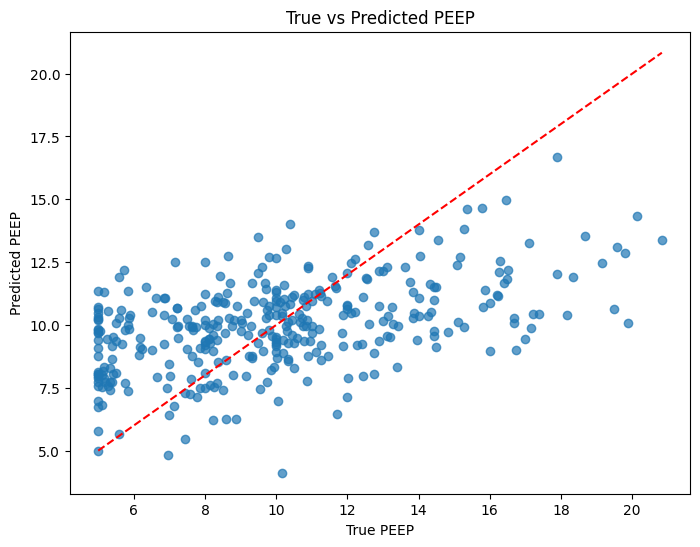

In [78]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Convert results to DataFrame
results_df = pd.DataFrame(results_list)

# Filter significant components based on p-value < 0.1
significant_components = results_df[results_df['P-Value'] < 0.1]['PCA Component']
print("Significant Components (P-Value < 0.1):")
print(significant_components)

# Prepare data with significant components for multivariate regression
X_significant = df[significant_components]

# Train a multivariate linear regression model on the entire dataset
model = LinearRegression()
model.fit(X_significant, y)

# Predict on the entire dataset
y_pred = model.predict(X_significant)

# Calculate R-squared value
r2 = r2_score(y, y_pred)
print(f"R-squared value: {r2}")

# Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculate Mean Absolute Error
mae = mean_absolute_error(y, y_pred)
print(f"Mean Absolute Error: {mae}")

# Calculate variance of the residuals (prediction errors)
variance = np.var(y_pred - y)
print(f"Variance: {variance}")

# Optionally, visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.xlabel('True PEEP')
plt.ylabel('Predicted PEEP')
plt.title('True vs Predicted PEEP')
plt.show()


Cross-Validation MSE scores: [12.28296828 11.54937592 10.05544833 10.4603607  10.32242916]
Mean CV MSE: 10.93411647847562


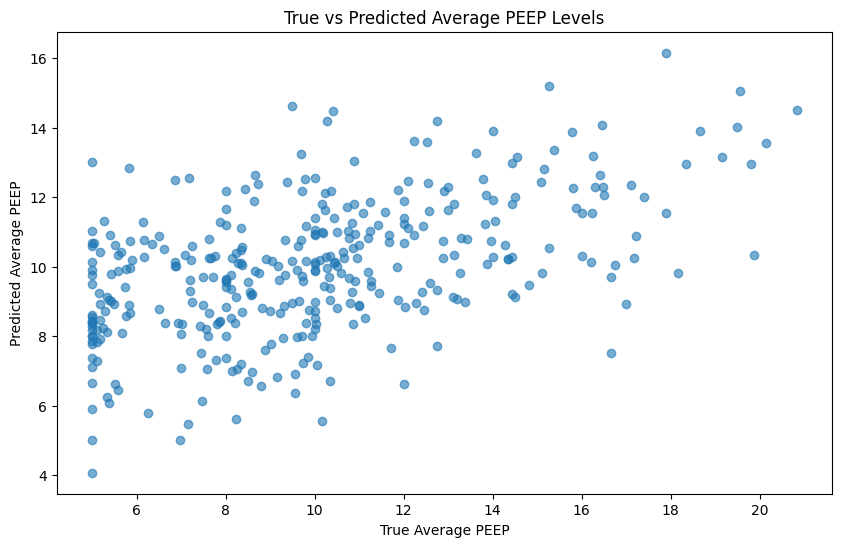


Correct Predictions:
Empty DataFrame
Columns: [study_id, subject_id, study_datetime, path, dicom_id, timezero, icu_mort, avg_peep, time_diff, embedding_0, embedding_1, embedding_2, embedding_3, embedding_4, embedding_5, embedding_6, embedding_7, embedding_8, embedding_9, embedding_10, embedding_11, embedding_12, embedding_13, embedding_14, embedding_15, embedding_16, embedding_17, embedding_18, embedding_19, embedding_20, embedding_21, embedding_22, embedding_23, embedding_24, embedding_25, embedding_26, embedding_27, embedding_28, embedding_29, embedding_30, embedding_31, embedding_32, embedding_33, embedding_34, embedding_35, embedding_36, embedding_37, embedding_38, embedding_39, embedding_40, embedding_41, embedding_42, embedding_43, embedding_44, embedding_45, embedding_46, embedding_47, embedding_48, embedding_49, embedding_50, embedding_51, embedding_52, embedding_53, embedding_54, embedding_55, embedding_56, embedding_57, embedding_58, embedding_59, embedding_60, embedding_61,

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
import matplotlib.pyplot as plt

# Assuming embeddings and avg_peep are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and avg_peep
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]

y = df['avg_peep']

# Apply PCA
pca = PCA(n_components=30)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(30)]]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_mse_scores = -cv_scores
print("Cross-Validation MSE scores:", cv_mse_scores)
print("Mean CV MSE:", np.mean(cv_mse_scores))

# Predict on the test set
y_pred = model.predict(X_test)

# Add predictions to the DataFrame
df['predicted_avg_peep'] = model.predict(X)

# Plot true vs predicted average PEEP levels
plt.figure(figsize=(10, 6))
plt.scatter(y, df['predicted_avg_peep'], alpha=0.6)
plt.xlabel('True Average PEEP')
plt.ylabel('Predicted Average PEEP')
plt.title('True vs Predicted Average PEEP Levels')
plt.show()

# Identify correct and incorrect predictions
test_indices = X_test.index
correct_predictions = test_indices[y_test == y_pred]
incorrect_predictions = test_indices[y_test != y_pred]

# Display some rows from the raw dataset where predictions were correct
print("\nCorrect Predictions:")
print(df.loc[correct_predictions].head())

# Display some rows from the raw dataset where predictions were incorrect
print("\nIncorrect Predictions:")
print(df.loc[incorrect_predictions].head())

         pca_1      pca_2      pca_3     pca_4     pca_5      pca_6     pca_7  \
345  -0.880360  -2.078076  -7.373032 -0.632758  6.441121   8.277784  5.119841   
332   7.580086   5.279175   2.722111 -6.489694 -3.821327 -12.302726 -0.738512   
183 -12.222613  -0.818084  10.831985 -1.268715 -1.773828  -0.087181  4.301722   
75   -4.560160  -3.755611  -0.408350 -0.304152  1.627185   0.590469 -2.173875   
336 -15.623697  -7.777978   0.624207  2.828564  3.642395   2.746637  1.707876   
..         ...        ...        ...       ...       ...        ...       ...   
71    6.526226  -7.676422   3.018350 -4.368575  3.735753  -2.867370 -3.904323   
106  25.563806 -13.851546   2.351954  5.170075 -7.581671  -1.592046  1.320343   
270  16.753437  -5.864125   9.222201  3.147776 -0.635400   1.164730  1.940025   
348  -0.875897   3.538682  -2.951371 -6.330294 -1.148130   1.563224 -0.422331   
102  13.661682 -11.392105  -2.823038  2.434110 -1.528773   4.478880  1.687931   

        pca_8     pca_9    

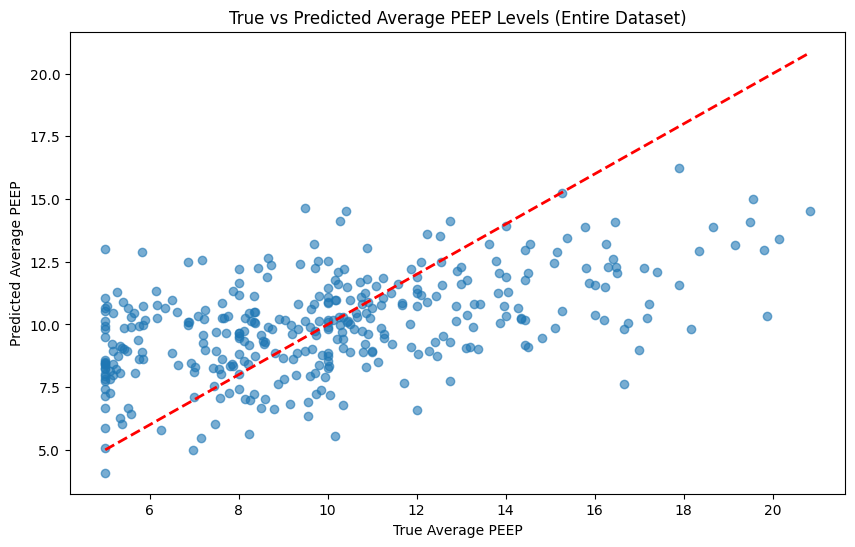

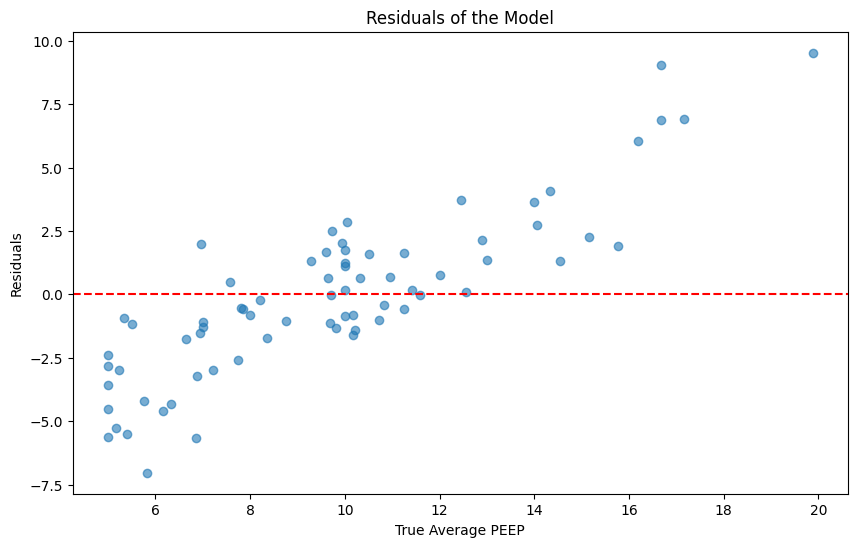

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Assuming df is already loaded and contains embeddings and avg_peep

# Extract embedding vectors and avg_peep
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
y = df['avg_peep']

# Apply PCA
pca = PCA(n_components=30)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(30)]]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
print (X_train)
# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_mse_scores = -cv_scores
print("Cross-Validation MSE scores:", cv_mse_scores)
print("Mean CV MSE:", np.mean(cv_mse_scores))

# Predict on the test set
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluation metrics
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

print(f"Train MSE: {train_mse}, Test MSE: {test_mse}")
print(f"Train RMSE: {train_rmse}, Test RMSE: {test_rmse}")
print(f"Train R2: {train_r2}, Test R2: {test_r2}")
print(f"Train MAE: {train_mae}, Test MAE: {test_mae}")

# Add predictions to the DataFrame
df['predicted_avg_peep'] = model.predict(X)

# Plot true vs predicted average PEEP levels
plt.figure(figsize=(10, 6))
plt.scatter(y, df['predicted_avg_peep'], alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('True Average PEEP')
plt.ylabel('Predicted Average PEEP')
plt.title('True vs Predicted Average PEEP Levels (Entire Dataset)')
plt.show()

# Plot residuals
residuals = y_test - y_pred_test
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('True Average PEEP')
plt.ylabel('Residuals')
plt.title('Residuals of the Model')
plt.show()


# Dicom images for correct/incorrect predictions (Linear Regression)


In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Download the DICOM file from the GCP bucket
blob = bucket.blob('prediction_datas/incorrect_predictions/X1.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()
# Download the DICOM file from the GCP bucket
blob = bucket.blob('prediction_datas/incorrect_predictions/X2.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()
# Download the DICOM file from the GCP bucket
blob = bucket.blob('prediction_datas/incorrect_predictions/X3.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

print ('End of incorrect predictions, now correct predictions')
# Download the DICOM file from the GCP bucket
blob = bucket.blob('prediction_datas/correct_predictions/O1.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()
# Download the DICOM file from the GCP bucket
blob = bucket.blob('prediction_datas/correct_predictions/O2.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()
# Download the DICOM file from the GCP bucket
blob = bucket.blob('prediction_datas/correct_predictions/O3.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Logistic Regression for high/low peep and high/middle/low peep

Cross-Validation Accuracy scores: [0.69444444 0.67605634 0.5915493  0.57746479 0.5915493 ]
Mean CV Accuracy: 0.6262128325508607


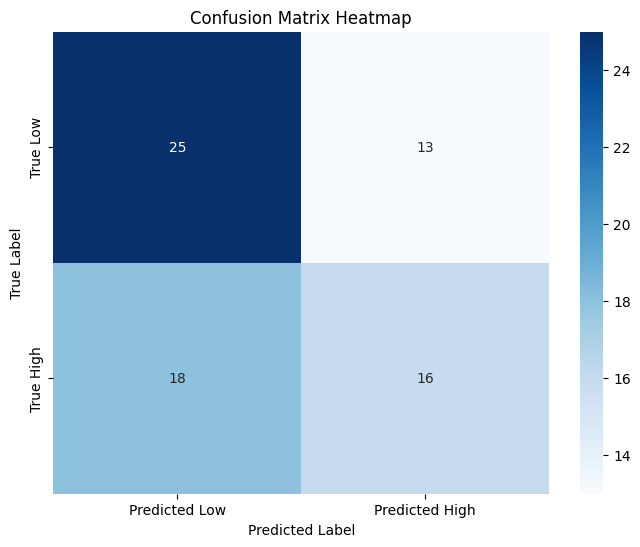

              precision    recall  f1-score   support

    Low PEEP       0.58      0.66      0.62        38
   High PEEP       0.55      0.47      0.51        34

    accuracy                           0.57        72
   macro avg       0.57      0.56      0.56        72
weighted avg       0.57      0.57      0.57        72


Correct Predictions:
     study_id  subject_id           study_datetime  \
256  54895239    16892349  2147-09-23 11:03:49.811   
15   55727793    10398981  2125-09-17 20:07:28.921   
140  52273723    13608861  2150-10-05 23:30:51.484   
294  53988069    18019452  2149-01-12 15:43:06.687   
82   59985023    11944377  2149-02-01 05:15:07.875   

                                  path  \
256  files/p16/p16892349/s54895239.txt   
15   files/p10/p10398981/s55727793.txt   
140  files/p13/p13608861/s52273723.txt   
294  files/p18/p18019452/s53988069.txt   
82   files/p11/p11944377/s59985023.txt   

                                         dicom_id             timezero  \

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming embeddings and avg_peep are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and avg_peep
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]

peep = df['avg_peep']
y = [1 if component >= 10 else 0 for component in peep]

# Apply PCA
pca = PCA(n_components=30)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(30)]]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Predict on the test set
y_pred = model.predict(X_test)

# Add predictions to the DataFrame
df['predicted_avg_peep'] = model.predict(X)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Low', 'Predicted High'], yticklabels=['True Low', 'True High'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Print the classification report
print(classification_report(y_test, y_pred, target_names=['Low PEEP', 'High PEEP']))

# Identify correct and incorrect predictions
test_indices = X_test.index
correct_predictions = test_indices[y_test == y_pred]
incorrect_predictions = test_indices[y_test != y_pred]

# Display some rows from the raw dataset where predictions were correct
print("\nCorrect Predictions:")
print(df.loc[correct_predictions].head())

# Display some rows from the raw dataset where predictions were incorrect
print("\nIncorrect Predictions:")
print(df.loc[incorrect_predictions].head())


Cross-Validation Accuracy scores: [0.68055556 0.67605634 0.5915493  0.5915493  0.5915493 ]
Mean CV Accuracy: 0.6262519561815336
Test Set Accuracy: 0.5694444444444444
Test Set Precision: 0.5517241379310345
Test Set Recall: 0.47058823529411764
Test Set F1 Score: 0.507936507936508
Confusion Matrix:
 [[25 13]
 [18 16]]


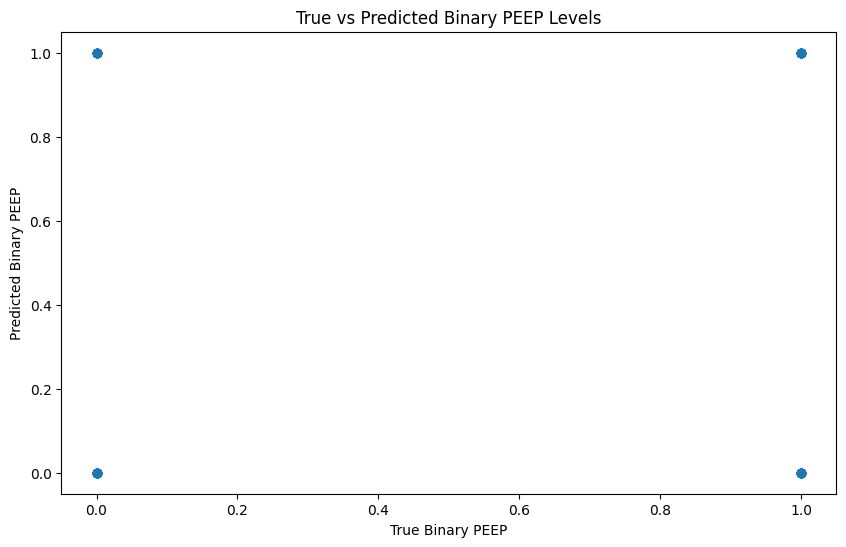

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# Assuming embeddings and avg_peep are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and avg_peep
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]

# Binarize the avg_peep values
peep = df['avg_peep']
y = [1 if component >= 10 else 0 for component in peep]

# Apply PCA
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(30)]]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate and print accuracy, precision, recall, and F1 score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Test Set Accuracy:", accuracy)
print("Test Set Precision:", precision)
print("Test Set Recall:", recall)
print("Test Set F1 Score:", f1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Plot true vs predicted average PEEP levels
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel('True Binary PEEP')
plt.ylabel('Predicted Binary PEEP')
plt.title('True vs Predicted Binary PEEP Levels')
plt.show()


Cross-Validation Accuracy scores: [0.47222222 0.4084507  0.36619718 0.4084507  0.42253521]
Mean CV Accuracy: 0.4155712050078247
Classification Report (Test Set):
              precision    recall  f1-score   support

          <8       0.50      0.46      0.48        26
        8-10       0.38      0.42      0.40        26
         >10       0.42      0.40      0.41        20

    accuracy                           0.43        72
   macro avg       0.43      0.43      0.43        72
weighted avg       0.43      0.43      0.43        72



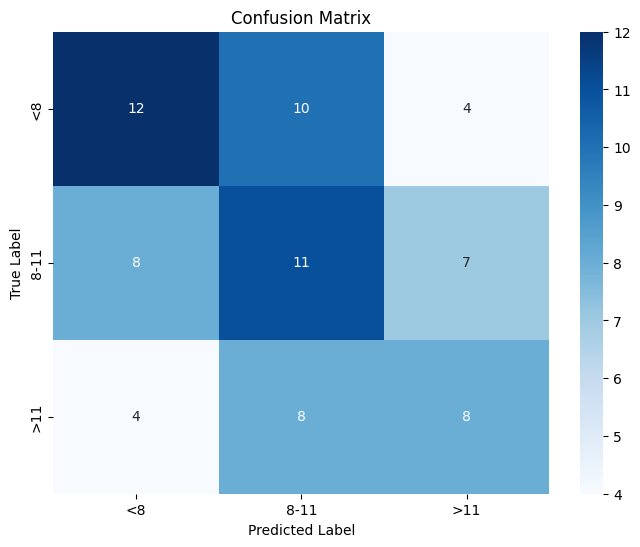

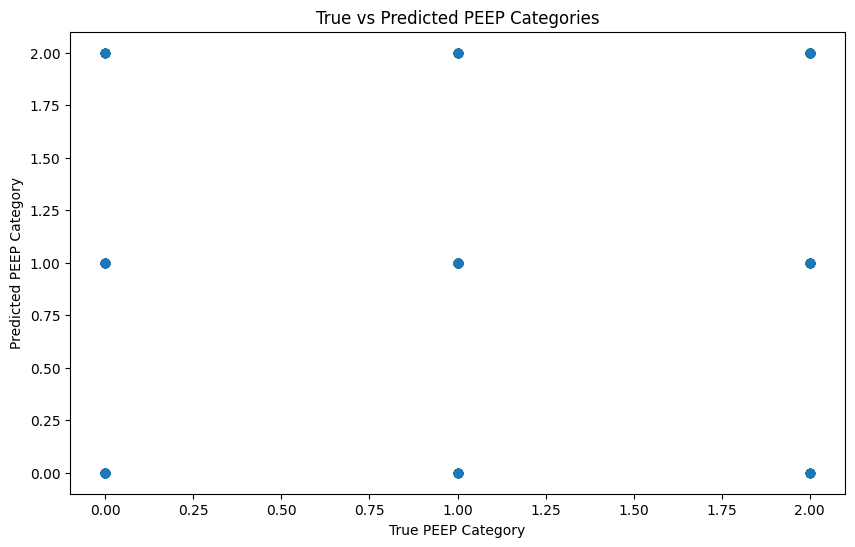

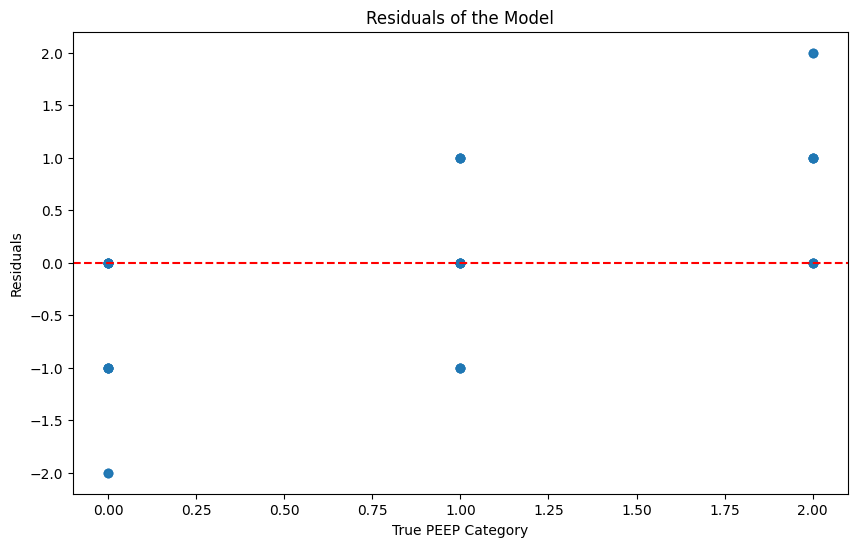


Correct Predictions:
     study_id  subject_id           study_datetime  \
227  54559838    15937220  2110-06-21 08:22:04.171   
15   55727793    10398981  2125-09-17 20:07:28.921   
140  52273723    13608861  2150-10-05 23:30:51.484   
82   59985023    11944377  2149-02-01 05:15:07.875   
352  51783801    19891610  2161-04-13 04:08:24.546   

                                  path  \
227  files/p15/p15937220/s54559838.txt   
15   files/p10/p10398981/s55727793.txt   
140  files/p13/p13608861/s52273723.txt   
82   files/p11/p11944377/s59985023.txt   
352  files/p19/p19891610/s51783801.txt   

                                         dicom_id             timezero  \
227  684d7097-5d2830af-d4c07329-fa06933e-817b1ae9  2110-06-21 16:49:00   
15   5f4221fa-5f528de5-78401294-c751a1b2-4496b23b  2125-09-17 20:36:00   
140  75d1e4b0-7bb9cdd8-a2aba215-e44817df-80ef8701  2150-10-06 03:57:00   
82   31a102b6-e48bb88c-6f7fa543-a359e525-58a8d187  2149-02-01 02:39:00   
352  84172a55-74e1771c-e63a592

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is already loaded and contains embeddings and avg_peep

# Extract embedding vectors and avg_peep
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
avg_peep = df['avg_peep']

# Create a new target variable with three classes
def categorize_peep(value):
    if value < 8:
        return 0
    elif 8 <= value <= 11:
        return 1
    else:
        return 2

y = avg_peep.apply(categorize_peep)

# Apply PCA
pca = PCA(n_components=30)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for classification analysis
X = df[[f'pca_{i+1}' for i in range(30)]]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression(multi_class='ovr')
model.fit(X_train, y_train)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Predict on the test set
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluation metrics
print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=['<8', '8-10', '>10']))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['<8', '8-11', '>11'], yticklabels=['<8', '8-11', '>11'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Add predictions to the DataFrame
df['predicted_peep_category'] = model.predict(X)

# Plot true vs predicted average PEEP categories
plt.figure(figsize=(10, 6))
plt.scatter(y, df['predicted_peep_category'], alpha=0.6)
plt.xlabel('True PEEP Category')
plt.ylabel('Predicted PEEP Category')
plt.title('True vs Predicted PEEP Categories')
plt.show()

# Plot residuals for the test set
residuals = y_test - y_pred_test
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('True PEEP Category')
plt.ylabel('Residuals')
plt.title('Residuals of the Model')
plt.show()

# Display some rows where the prediction was correct
correct_predictions = y_test == y_pred_test
print("\nCorrect Predictions:")
print(df.loc[X_test.index[correct_predictions]].head())

# Display some rows where the prediction was incorrect
incorrect_predictions = y_test != y_pred_test
print("\nIncorrect Predictions:")
print(df.loc[X_test.index[incorrect_predictions]].head())


# Logistic regression optimization

Selected PCA Components: [ 6 18 26 34 35 37 38 42 43 44]
Cross-Validation Accuracy scores: [0.63888889 0.66197183 0.50704225 0.70422535 0.63380282]
Mean CV Accuracy: 0.6291862284820031


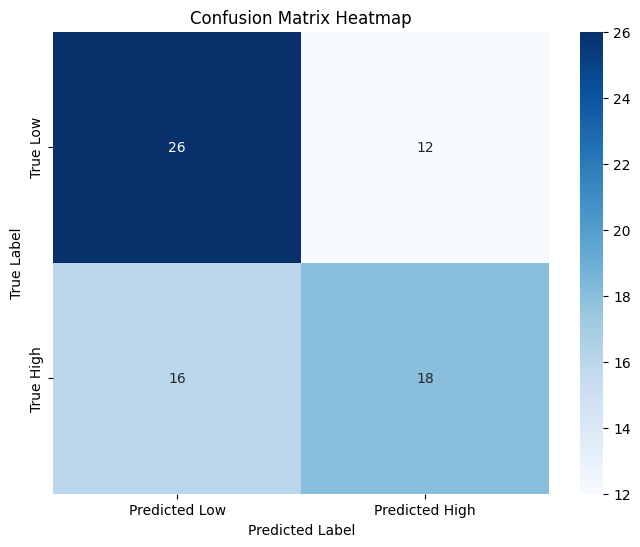

              precision    recall  f1-score   support

    Low PEEP       0.62      0.68      0.65        38
   High PEEP       0.60      0.53      0.56        34

    accuracy                           0.61        72
   macro avg       0.61      0.61      0.61        72
weighted avg       0.61      0.61      0.61        72


Correct Predictions:
     study_id  subject_id           study_datetime  \
256  54895239    16892349  2147-09-23 11:03:49.811   
333  58437052    19040738  2143-06-14 05:33:34.453   
140  52273723    13608861  2150-10-05 23:30:51.484   
294  53988069    18019452  2149-01-12 15:43:06.687   
82   59985023    11944377  2149-02-01 05:15:07.875   

                                  path  \
256  files/p16/p16892349/s54895239.txt   
333  files/p19/p19040738/s58437052.txt   
140  files/p13/p13608861/s52273723.txt   
294  files/p18/p18019452/s53988069.txt   
82   files/p11/p11944377/s59985023.txt   

                                         dicom_id             timezero  \

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming embeddings and avg_peep are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and avg_peep
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
peep = df['avg_peep']

# Binarize the avg_peep values
y = [1 if value >= 10 else 0 for value in peep]

# Apply PCA
chosen_components = 50
pca = PCA(n_components=chosen_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(chosen_components)]]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression(max_iter=1000000)

# Use Recursive Feature Elimination (RFE) to find the best subset of PCA components
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X_train, y_train)

# Selected features
selected_features = np.where(rfe.support_)[0] + 1
print(f"Selected PCA Components: {selected_features}")

# Retrain the model using the selected PCA components
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)
model.fit(X_train_rfe, y_train)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, rfe.transform(X), y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Predict on the test set
y_pred = model.predict(X_test_rfe)

# Add predictions to the DataFrame
df['predicted_avg_peep'] = model.predict(rfe.transform(X))

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Low', 'Predicted High'], yticklabels=['True Low', 'True High'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Print the classification report
print(classification_report(y_test, y_pred, target_names=['Low PEEP', 'High PEEP']))

# Identify correct and incorrect predictions
test_indices = X_test.index
correct_predictions = test_indices[y_test == y_pred]
incorrect_predictions = test_indices[y_test != y_pred]

# Display some rows from the raw dataset where predictions were correct
print("\nCorrect Predictions:")
print(df.loc[correct_predictions].head())

# Display some rows from the raw dataset where predictions were incorrect
print("\nIncorrect Predictions:")
print(df.loc[incorrect_predictions].head())


Best parameters: {'alpha': 100.0}
Cross-Validation MSE scores: [12.39343708 11.52099798  9.93996453 10.11186921 10.00890635]
Mean CV MSE: 10.795035031144684
Cross-Validation MAE scores: [2.74798702 2.74416642 2.65694912 2.54677157 2.51121432]
Mean CV MAE: 2.6414176897898716
Test Set MSE: 10.40286425540058
Test Set MAE: 2.4234298011939663


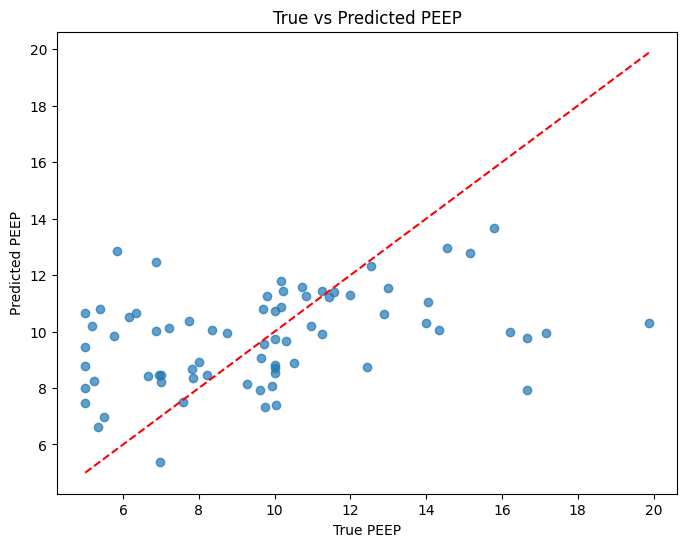


Correct Predictions:
     study_id  subject_id           study_datetime  \
42   56080537    10999395  2148-03-14 12:54:35.671   
140  52273723    13608861  2150-10-05 23:30:51.484   
352  51783801    19891610  2161-04-13 04:08:24.546   
119  51361865    13098601  2164-09-20 15:40:41.593   
126  58090034    13243522  2125-12-03 13:17:35.359   

                                  path  \
42   files/p10/p10999395/s56080537.txt   
140  files/p13/p13608861/s52273723.txt   
352  files/p19/p19891610/s51783801.txt   
119  files/p13/p13098601/s51361865.txt   
126  files/p13/p13243522/s58090034.txt   

                                         dicom_id             timezero  \
42   5af211b6-f688bb75-ee00bbc6-59f99556-22213c58  2148-03-14 22:10:00   
140  75d1e4b0-7bb9cdd8-a2aba215-e44817df-80ef8701  2150-10-06 03:57:00   
352  84172a55-74e1771c-e63a592d-b646ffc4-4ec2d3e5  2161-04-13 03:45:00   
119  19bd6be3-aed04b55-928e328e-3cc150f2-d72be08d  2164-09-20 18:23:00   
126  4b2f4608-ca1e13f5-d7010dc

In [13]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming embeddings and avg_peep are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and avg_peep
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]

peep = df['avg_peep']

# Apply PCA
pca = PCA(n_components=30)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(30)]]
y = peep

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the regression model
model = Ridge()

# Perform cross-validation and hyperparameter tuning
param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Best model from grid search
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# Train the best model on the full training set
best_model.fit(X_train, y_train)

# Cross-validation scores
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_scores_mae = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_absolute_error')
print("Cross-Validation MSE scores:", -cv_scores)
print("Mean CV MSE:", -np.mean(cv_scores))
print("Cross-Validation MAE scores:", -cv_scores_mae)
print("Mean CV MAE:", -np.mean(cv_scores_mae))

# Predict on the test set
y_pred = best_model.predict(X_test)

# Calculate and print regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("Test Set MSE:", mse)
print("Test Set MAE:", mae)

# Plot the true vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('True PEEP')
plt.ylabel('Predicted PEEP')
plt.title('True vs Predicted PEEP')
plt.show()

# Identify correct and incorrect predictions
test_indices = X_test.index
correct_predictions = test_indices[np.abs(y_test - y_pred) < 1]  # Tolerance can be adjusted
incorrect_predictions = test_indices[np.abs(y_test - y_pred) >= 1]

# Display some rows from the raw dataset where predictions were correct
print("\nCorrect Predictions:")
print(df.loc[correct_predictions].head())

# Display some rows from the raw dataset where predictions were incorrect
print("\nIncorrect Predictions:")
print(df.loc[incorrect_predictions].head())
